In [96]:
import sys
sys.path.append("../../src/")
import numerical_quenches as nq
from project_imports import *


In [2]:
nq.g_linear_hold?

Signature: nq.g_linear_hold(t, args)
Docstring:
args = tau,tf
A linear quench of the form 1-t/tau
when t>tf:
1-tf/tau
File:      ~/Desktop/subsystem_loschmidt_echo/src/numerical_quenches.py
Type:      function

In [97]:
L = 100
tau = 10
g0=5
tf = tau 
args = (tau,tf)
t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,10), np.linspace(tau+.001,tau+10,1000)))
#t_eval = np.linspace(-(g0-1)*tau,tau,10)#np.concatenate((np.linspace(-(g0-1)*tau,tf,10),np.linspace(tf+.001,10,100)))
states= nq.states(L,t_eval,nq.g_linear_hold,args)

g0=5.0


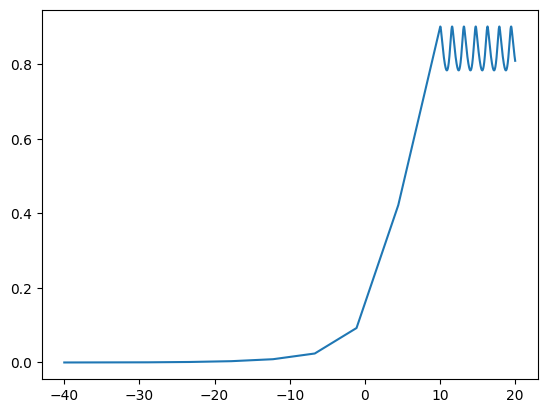

In [98]:
IS = nq.groundstate(g0,L)
plot(t_eval,-log(nq.overlap(states,IS)**2)/L)

In [99]:
def groundstate(g,k):


    V0 = la.eigh(nq.BdG(k, g))[1][:, 1]
    u = V0[0]
    v= V0[1]

    return u,v,k


In [100]:
pi-sqrt(log(4)/pi)/(2*sqrt(tau))-.15

np.float64(2.8865603728013016)

In [101]:
v0

np.complex128(0.9999962472232289j)

In [102]:
1/.048

20.833333333333332

In [103]:
print(pi-sqrt(log(2)/2/pi/tau))
print(kstar)

pi-np.asin(sqrt(log(2)/pi/tau))


3.0365603728013015
3.11967234337301


np.float64(2.992502869043839)

In [115]:
np.clip?

Signature:      
np.clip(
    a,
    a_min=<no value>,
    a_max=<no value>,
    out=None,
    *,
    min=<no value>,
    max=<no value>,
    **kwargs,
)
Call signature:  np.clip(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function clip at 0x1069439c0>
File:            ~/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/_core/fromnumeric.py
Docstring:      
Clip (limit) the values in an array.

Given an interval, values outside the interval are clipped to
the interval edges.  For example, if an interval of ``[0, 1]``
is specified, values smaller than 0 become 0, and values larger
than 1 become 1.

Equivalent to but faster than ``np.minimum(a_max, np.maximum(a, a_min))``.

No check is performed to ensure ``a_min < a_max``.

Parameters
----------
a : array_like
    Array containing elements to clip.
a_min, a_max : array_like or None
    Minimum and maximum value. If ``None``, clipping is not performed on
    the corresponding edge. If both ``a_min``

In [342]:
np.acos(sqrt(2*np.abs(vs[1])))

np.float64(1.371771726063792)

In [399]:
abs(vs[1])

np.float64(0.019545270586842797)

In [ ]:
2-2*sin(2./2)

np.float64(0.014574017924823046)

In [298]:
import numpy as np

phase = np.angle(us[1])
u_rot = us[1] * np.exp(-1j*phase)
v_rot = vs[1] * np.exp(-1j*phase)

pi-np.acos(abs(u_rot)**2)

np.float64(2.614852942367997)

np.complex128(1j)

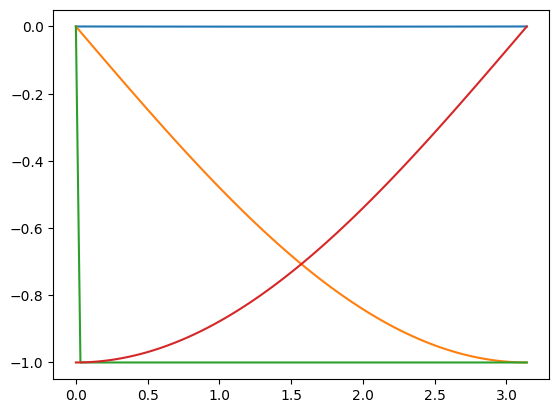

In [432]:
k = np.linspace(0,pi,100)
dat=[]
dat2=[]
for ki in k:
    uf,vf,kf = groundstate(1000,ki)
    dat.append(uf)
    dat2.append(vf)
dat2=array(dat2)
plot(k,dat)
plot(k,-sin(k/2))

plot(k,1j*dat2)
plot(k,-cos(k/2))

(-0.002291927996657621+0j) 0.9999973735295798j
0.08613547881927947


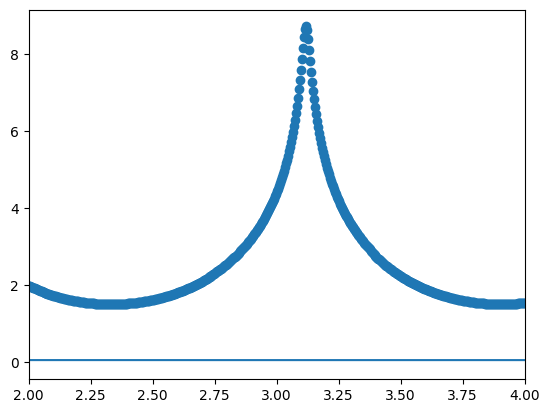

In [445]:
tau = 2
g0=100
tf = tau
args = (tau,tf)

dat=[]

kstar= 2.67
u0,v0,k0 = groundstate(g0,kstar)
print(u0,v0)
uf,vf,kf = groundstate(0,kstar)
t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,1), np.linspace(tau+.0000001,tau+.0000002,2)))
us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)

print(sin(kstar)-np.abs(vs[1]))
t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,2), np.linspace(tau+.0000001,tau+2,500)))


us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)

Final_overlap = np.abs(np.conj(vf)*us+np.conj(uf)*vs)**2

LE= np.abs(np.conj(us[0])*us+np.conj(vs[0])*vs)**2
scatter(t_eval,-log(LE))
#ylim(-.1,1.1)
xlim(tau,t_eval[-1])
plot(t_eval,Final_overlap)

100%|██████████| 30/30 [01:35<00:00,  3.20s/it]


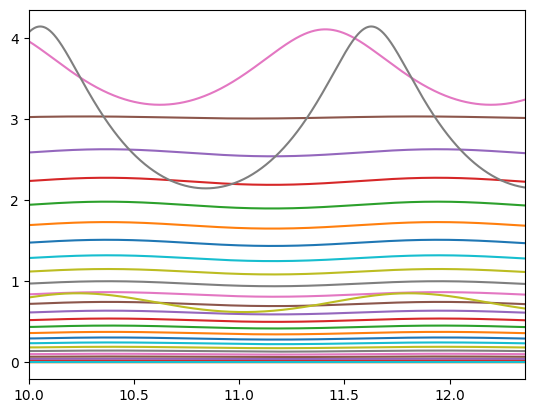

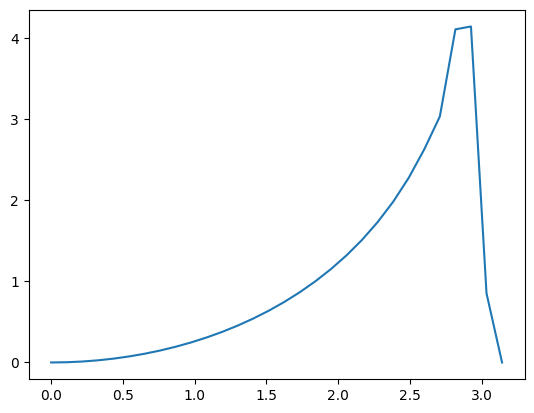

In [424]:
tau = 10
g0=40
tf = tau-.01
args = (tau,tf)

ks = np.linspace(0,pi,30)
dat=[]
for k in tqdm(ks):
    kstar = k#pi-sqrt(log(4)/pi)/(2*sqrt(tau))
    t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,10), np.linspace(tau+.001,tau+3*pi/4,1000)))

    u0,v0,k0 = groundstate(g0,kstar)

    us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
    LE = np.abs(np.conj(u0)*us+np.conj(v0)*vs)**2
    #plot(t_eval,LE)
    dat.append(max(-log(LE)))
    plot(t_eval,-log(LE))
    xlim(tau,t_eval[-1])
show()
plot(ks,dat)


In [425]:
tau = 50
g0=40
tf = tau-.01
args = (tau,tf)

ks = np.linspace(0,pi,30)
dat=[]
for k in tqdm(ks):
    kstar = k#pi-sqrt(log(4)/pi)/(2*sqrt(tau))
    t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,10), np.linspace(tau+.001,tau+3*pi/4,1000)))

    u0,v0,k0 = groundstate(g0,kstar)

    us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
    LE = np.abs(np.conj(u0)*us+np.conj(v0)*vs)**2
    #plot(t_eval,LE)
    dat.append(max(-log(LE)))
    plot(t_eval,-log(LE))
    xlim(tau,t_eval[-1])
show()
plot(ks,dat)


  0%|          | 0/30 [00:10<?, ?it/s]


KeyboardInterrupt: 

In [410]:
# Comparison to the final ground state at g=0
uf_0, vf_0, _ = groundstate(0, kstar)
LE_final = np.abs(np.conj(uf_0)*us + np.conj(vf_0)*vs)**2
LE_final

array([0.0028981 , 0.00291671, 0.0029409 , ..., 0.49753918, 0.49753863,
       0.4975381 ], shape=(1010,))

In [411]:
np.abs(np.conj(uf_0)*us[-1] + np.conj(vf_0)*vs[-1])**2

np.float64(0.49753809759308576)

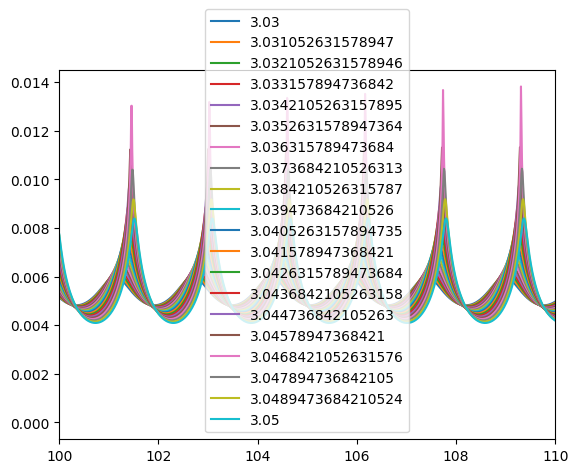

In [224]:
L = 1000
tau = 100
g0=5
tf = tau 
args = (tau,tf)
ks = np.linspace(3.03,3.05,20)

for kstar in ks:
    t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,10), np.linspace(tau+.001,tau+10,1000)))

    u0,v0,k0 = groundstate(g0,kstar)

    us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
    LE = np.abs(np.conj(u0)*us+np.conj(v0)*vs)**2

    plot(t_eval,-log(LE)/L,label=kstar)
    xlim(tau,t_eval[-1])
legend()

0.0
0.23020515378284184
0.5005033283238489


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_67860/667949939.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


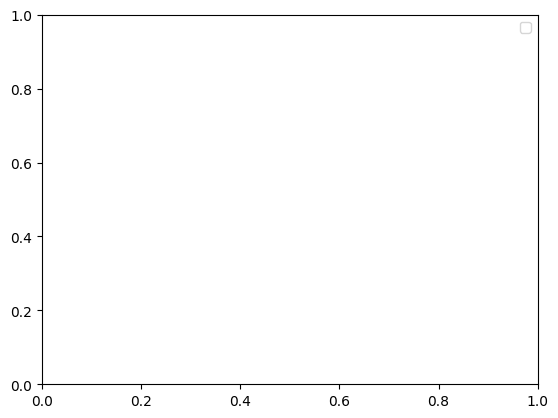

In [139]:
L = 1000
tau = .0000001
g0=1000
tf = tau 
args = (tau,tf)
ks = [0, 1, pi/2]

for kstar in ks:
    t_eval = (np.linspace(-(g0-1)*tau,tau,10))

    u0,v0,k0 = groundstate(g0,kstar)
    uf,vf,kf = groundstate(0,kstar)
    us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
    
    u_t = us[-1]
    v_t = vs[-1]

    Pk = abs(np.conj(uf)*v_t - np.conj(vf)*u_t)**2
    print(Pk)
legend()

In [161]:
pi/4

0.7853981633974483

100%|██████████| 100/100 [00:20<00:00,  4.81it/s]


(1.5707963267948966, 3.141592653589793)

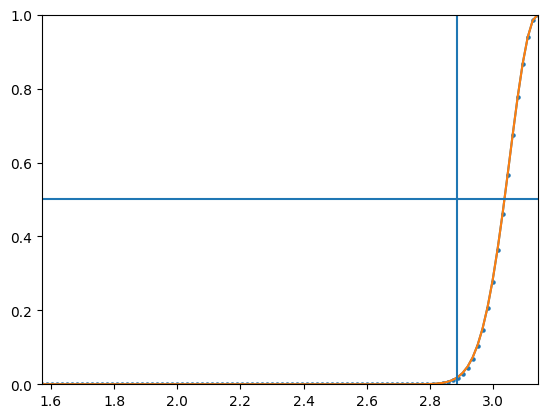

In [656]:
import kibble_zurek as kz
tau = 10
k = np.linspace(pi/2,pi,100)
g0=10
dat=[]
t_eval = (np.linspace(-(g0-1)*tau,tau,10))
tf = tau 
args = (tau,tf)

dat2=[]
for ki in tqdm(k):
    uf,vf,kf = groundstate(0,ki)
    u= kz.u_tilde(tau,ki,tau)
    v= kz.v_tilde(tau,ki,tau)

    u0,v0,k0 = groundstate(g0,ki)

    us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)


    dat.append(abs(np.conj(uf)*v + np.conj(vf)*u)**2)
    dat2.append(abs(np.conj(uf)*vs[-1]+np.conj(vf)*us[-1])**2)
plot(k,dat)
plot(k,dat2)
scatter(k,np.exp(-2*pi*tau*(pi-k)*(pi-k)),s=5)
plt.vlines(pi-sqrt(log(4)/pi)/(2*sqrt(tau))-.15,0,pi)
plt.hlines(1/2,0,pi)
ylim(0,1)
xlim(k[0],k[-1])
#plot(k,np.exp(-2*pi*tau*sin(k)**2))

In [284]:
def Pk_end_of_ramp(L, g0, tau, tf, ki):
    # initial spinor = your "groundstate" eigenvector at g0 (same convention as you evolve)
    V0 = la.eigh(nq.BdG(ki, g0))[1][:, 1]
    u0, v0 = V0[0], V0[1]

    # evolve to tf (use a t_eval that includes tf exactly)
    t_eval = np.array([-(g0-1)*tau, tf])
    us, vs = nq.evolve_mode(ki, nq.g_linear_hold, t_eval, u0, v0, (tau, tf))
    psi_tf = np.array([us[-1], vs[-1]])

    # final eigenbasis at gf=0
    evals, evecs = la.eigh(nq.BdG(ki, 0.0))
    # excited = opposite of what you call "ground" (index 0 vs 1); use eigenvalue ordering
    ve = evecs[:, 0]   # smaller eigenvalue eigenvector
    vg = evecs[:, 1]   # larger eigenvalue eigenvector

    # excitation probability in final basis (sum check: |<vg|psi>|^2 + |<ve|psi>|^2 = 1)
    Pexc = abs(np.vdot(ve, psi_tf))**2
    return Pexc

def predict_kstar(L, g0, tau, tf=None):
    if tf is None: tf = tau
    n = np.arange(0, L//2)
    kgrid = (2*n + 1) * np.pi / L
    P = np.array([Pk_end_of_ramp(L, g0, tau, tf, ki) for ki in tqdm(kgrid)])
    idx = np.argmin(np.abs(P - 0.5))
    return kgrid[idx], P[idx], kgrid, P

In [286]:
kstar, Pstar, kgrid, P = predict_kstar(1000, 10, 1, tf=1)































































































































































































































100%|██████████| 500/500 [00:12<00:00, 41.49it/s]


In [289]:
from scipy.optimize import brentq

def Pk_continuous(k, g0, tau, tf=None):
    if tf is None:
        tf = tau

    # initial ground spinor at g0
    V0 = la.eigh(nq.BdG(k, g0))[1][:, 1]
    u0, v0 = V0[0], V0[1]

    # evolve exactly to tf
    t_eval = np.array([-(g0-1)*tau, tf])
    us, vs = nq.evolve_mode(k, nq.g_linear_hold, t_eval, u0, v0, (tau, tf))
    psi_tf = np.array([us[-1], vs[-1]])

    # final eigenbasis at gf = g_linear_hold(tf)
    gf = nq.g_linear_hold(tf, (tau, tf))
    evals, evecs = la.eigh(nq.BdG(k, gf))

    # excited eigenvector = lower eigenvalue column (check sign if needed)
    ve = evecs[:, 0]

    return abs(np.vdot(ve, psi_tf))**2

In [301]:
def F(k, g0, tau):
    return Pk_continuous(k, g0, tau) - 0.5

g0=10
tau=100

In [302]:
kstar = brentq(F, 0.7*np.pi, np.pi, args=(g0, tau))

In [303]:
kstar

3.1083719883530305

In [304]:
pi-sqrt(log(4)/pi)/(2*sqrt(tau))

np.float64(3.1083785300763953)

In [ ]:
tau = 10
g0=40
tf = tau-.01
args = (tau,tf)

ks = np.linspace(0,pi,30)
dat=[]
for k in tqdm(ks):
    kstar = k#pi-sqrt(log(4)/pi)/(2*sqrt(tau))
    t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,10), np.linspace(tau+.001,tau+3*pi/4,1000)))

    u0,v0,k0 = groundstate(g0,kstar)

    us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
    LE = np.abs(np.conj(u0)*us+np.conj(v0)*vs)**2
    #plot(t_eval,LE)
    dat.append(max(-log(LE)))
    plot(t_eval,-log(LE))
    xlim(tau,t_eval[-1])
show()
plot(ks,dat)


In [432]:
taus = np.logspace(-2,2,100)
g0 = 5

kstars = []
peakvals = []

for tau in tqdm(taus):

    tf = tau
    args = (tau, tf)

    ks = np.linspace(0, np.pi, 500)
    dat = []

    for k in ks:

        t_eval = np.concatenate((
            np.linspace(-(g0-1)*tau, tau, 10),
            np.linspace(tau+0.001, tau+3*np.pi/4, 1000)
        ))

        u0, v0, _ = groundstate(g0, k)
        us, vs = nq.evolve_mode(k, nq.g_linear_hold, t_eval, u0, v0, args)

        LE = np.abs(np.conj(u0)*us + np.conj(v0)*vs)**2
        dat.append(np.max(-np.log(LE)))

    dat = np.array(dat)
    idx = np.argmax(dat)

    kstars.append(ks[idx])
    peakvals.append(dat[idx])

# plot k* vs tau
plt.figure()
plt.plot(taus, kstars, 'o-')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$k^*(\tau)$')
plt.show()

 87%|████████▋ | 87/100 [26:37<03:58, 18.37s/it]


KeyboardInterrupt: 

In [460]:
taus = np.logspace(1,2.5,10)
g0 = 1.1

kstars = []
peakvals = []

for tau in tqdm(taus):

    tf = tau
    args = (tau, tf)

    ks = np.linspace(0, np.pi, 400)
    dat = []

    for k in ks:

        t_eval = np.concatenate((
            np.linspace(-(g0-1)*tau, tau, 10),
            np.linspace(tau+0.001, tau+3*np.pi/4, 1000)
        ))

        u0, v0, _ = groundstate(g0, k)
        us, vs = nq.evolve_mode(k, nq.g_linear_hold, t_eval, u0, v0, args)

        LE = np.abs(np.conj(u0)*us + np.conj(v0)*vs)**2
        dat.append(np.max(-np.log(LE)))

    dat = np.array(dat)
    idx = np.argmax(dat)

    kstars.append(ks[idx])
    peakvals.append(dat[idx])

# plot k* vs tau
plt.figure()
plt.plot(taus, kstars, 'o-')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$k^*(\tau)$')
plt.show()

 90%|█████████ | 9/10 [09:09<01:01, 61.11s/it]


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

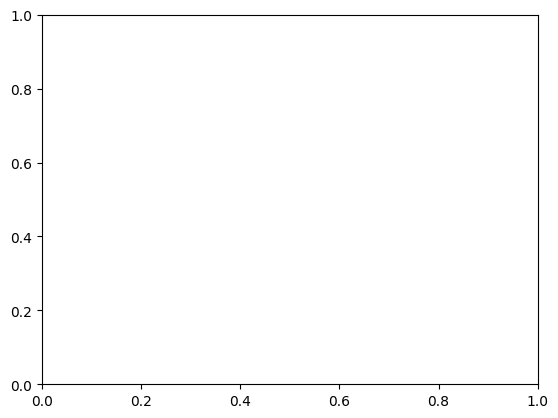

In [ ]:
plot(taus, np.abs(array(kstars)-pi))
plot(taus,taus**(-1/2))
loglog()

100%|██████████| 30/30 [00:19<00:00,  1.55it/s]


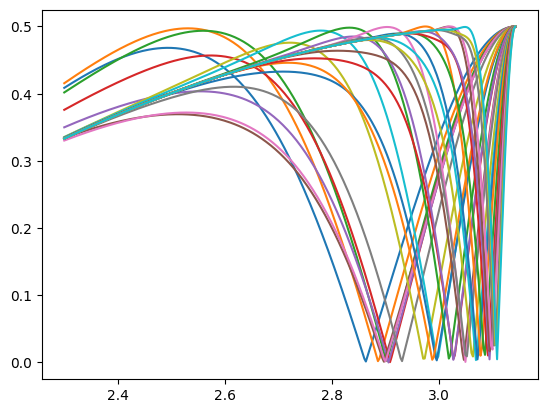

In [557]:
taus = np.logspace(0.01,2,30)
good_dat=[]
for tau in tqdm(taus):
    qs= linspace(2.3,pi,300)
    dat= array([np.abs(1/2-np.abs(kz.v_tilde(tau,q,tau))**2) for q in qs])
    plot(qs,dat)
    good_dat.append(qs[np.argmin(dat)])

[]

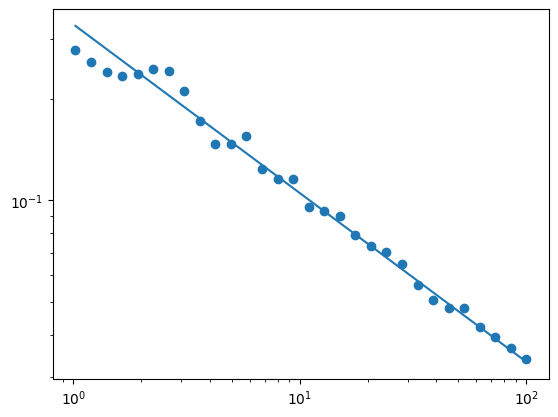

In [558]:
good_dat=array(good_dat)
scatter(taus,pi-good_dat)
plot(taus,(2*pi*taus/log(2))**(-1/2))
loglog()

  0%|          | 0/200 [00:00<?, ?it/s]

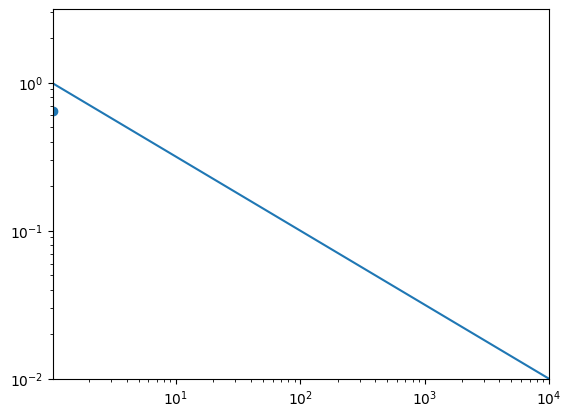

  0%|          | 1/200 [00:00<02:55,  1.14it/s]

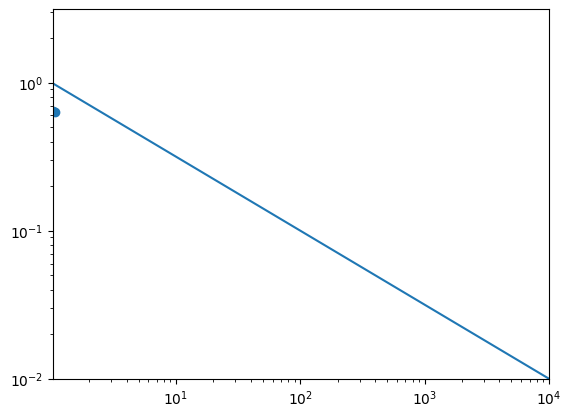

  1%|          | 2/200 [00:01<02:51,  1.16it/s]

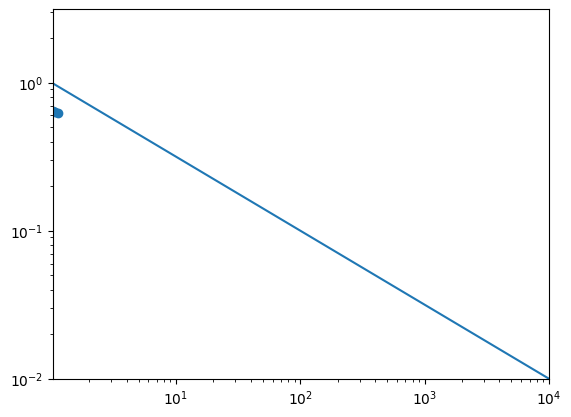

  2%|▏         | 3/200 [00:02<02:49,  1.16it/s]

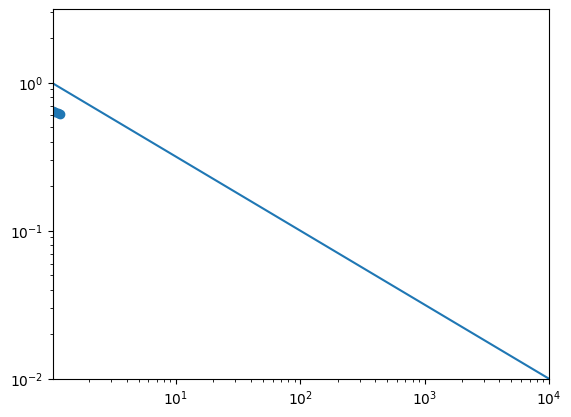

  2%|▏         | 4/200 [00:03<02:47,  1.17it/s]

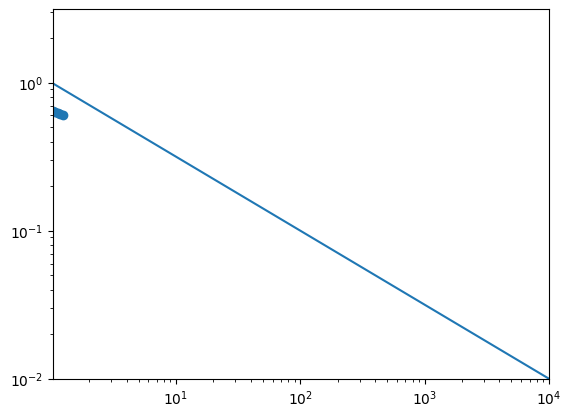

  2%|▎         | 5/200 [00:04<02:46,  1.17it/s]

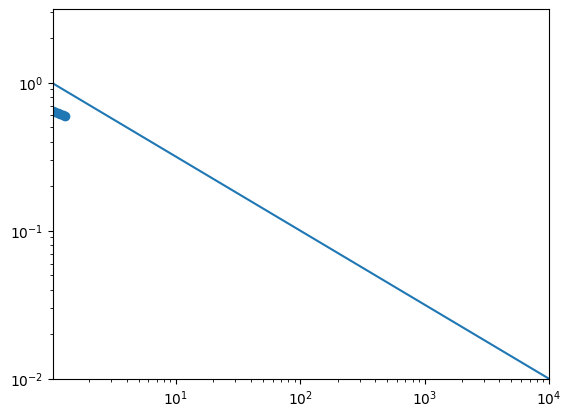

  3%|▎         | 6/200 [00:05<02:44,  1.18it/s]

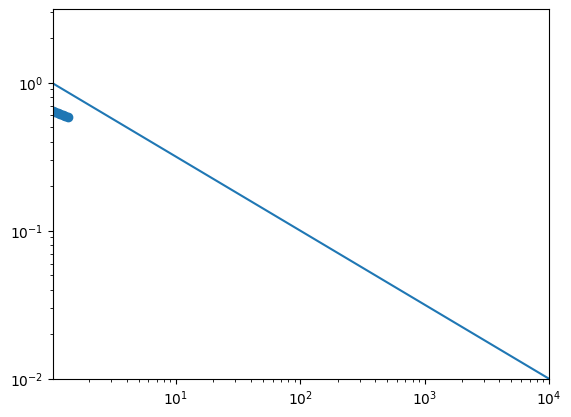

  4%|▎         | 7/200 [00:05<02:45,  1.17it/s]

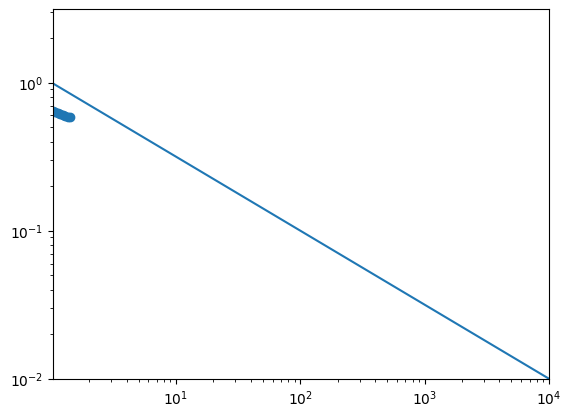

  4%|▍         | 8/200 [00:06<02:42,  1.18it/s]

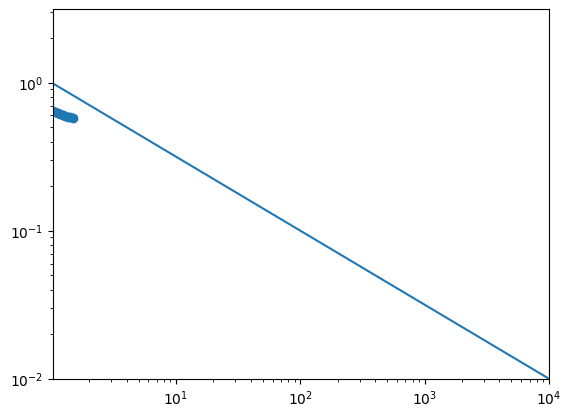

  4%|▍         | 9/200 [00:07<02:39,  1.20it/s]

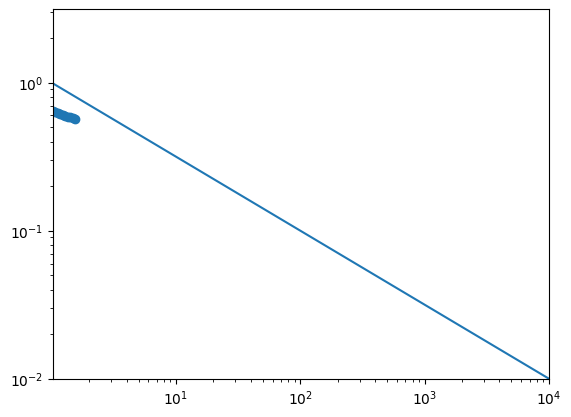

  5%|▌         | 10/200 [00:08<02:41,  1.18it/s]

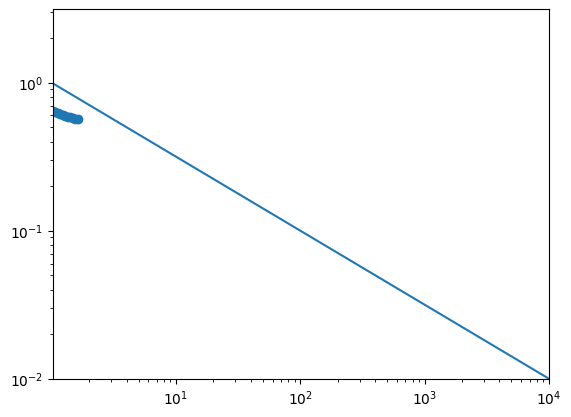

  6%|▌         | 11/200 [00:09<02:42,  1.16it/s]

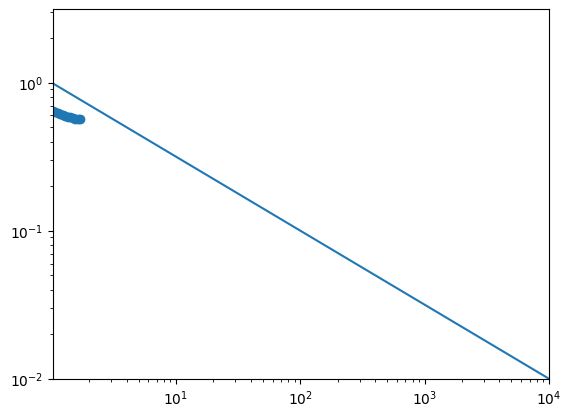

  6%|▌         | 12/200 [00:10<02:57,  1.06it/s]

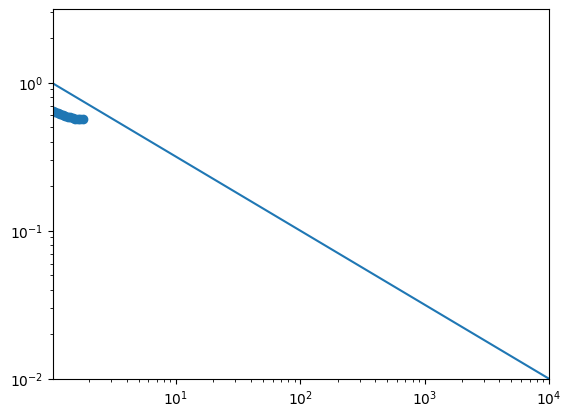

  6%|▋         | 13/200 [00:11<02:52,  1.08it/s]

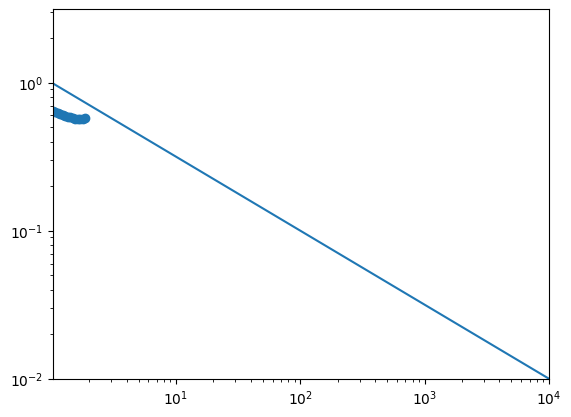

  7%|▋         | 14/200 [00:12<02:50,  1.09it/s]

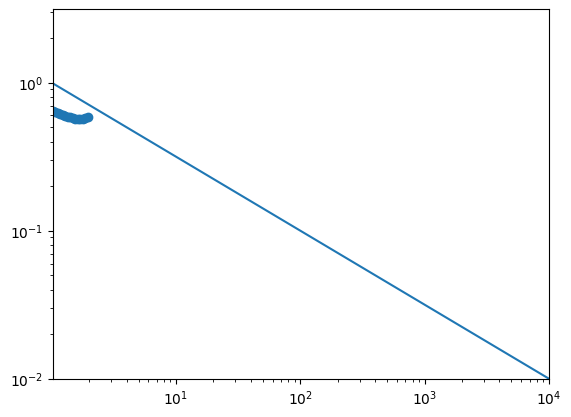

  8%|▊         | 15/200 [00:13<02:44,  1.12it/s]

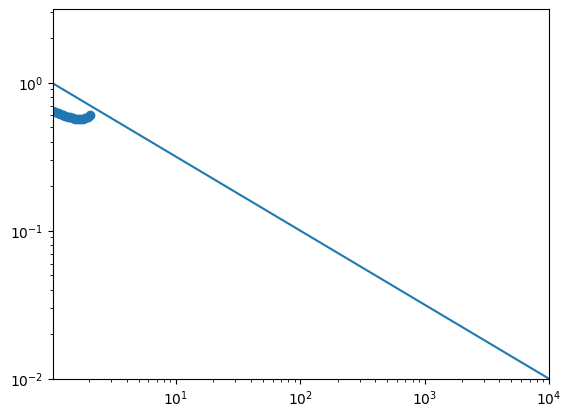

  8%|▊         | 16/200 [00:14<02:42,  1.13it/s]

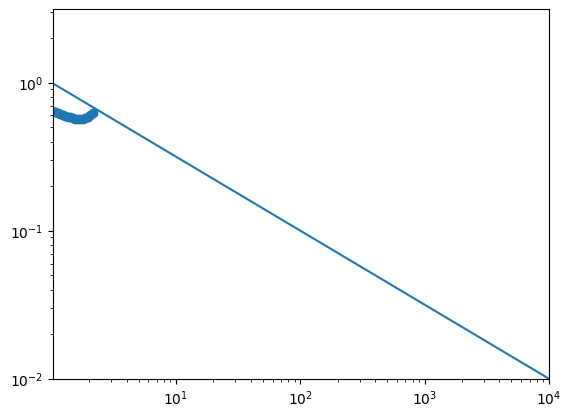

  8%|▊         | 17/200 [00:14<02:38,  1.16it/s]

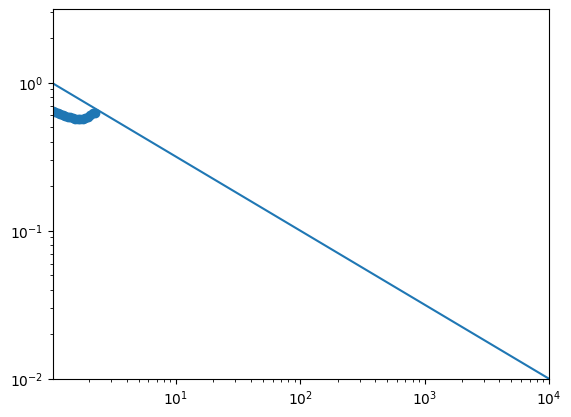

  9%|▉         | 18/200 [00:15<02:35,  1.17it/s]

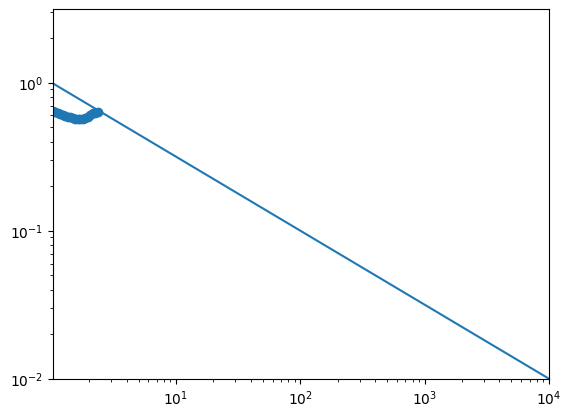

 10%|▉         | 19/200 [00:16<02:33,  1.18it/s]

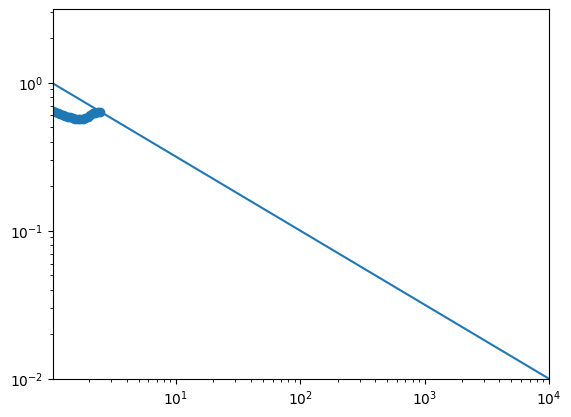

 10%|█         | 20/200 [00:17<02:31,  1.19it/s]

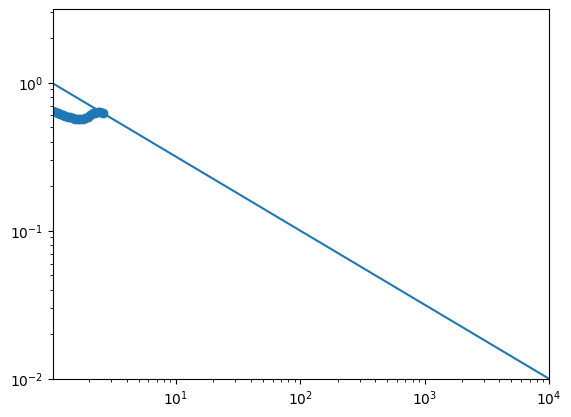

 10%|█         | 21/200 [00:18<02:30,  1.19it/s]

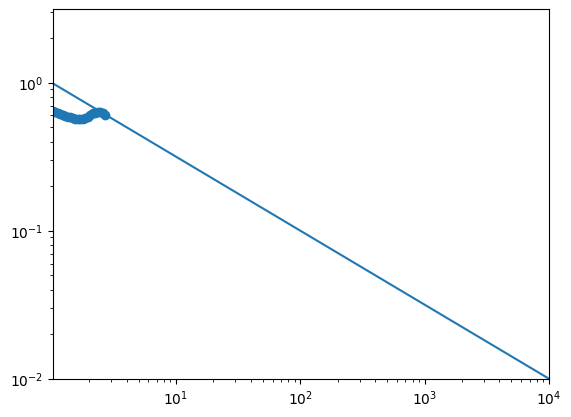

 11%|█         | 22/200 [00:18<02:27,  1.20it/s]

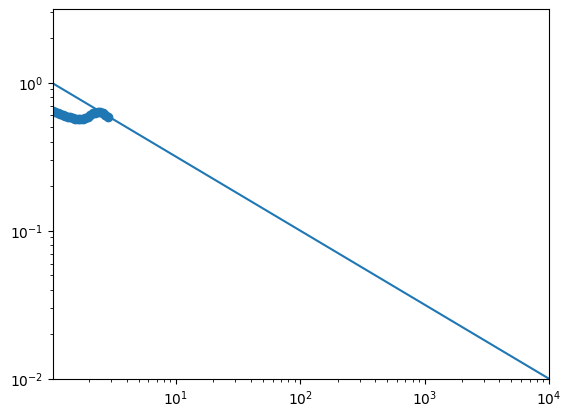

 12%|█▏        | 23/200 [00:19<02:26,  1.21it/s]

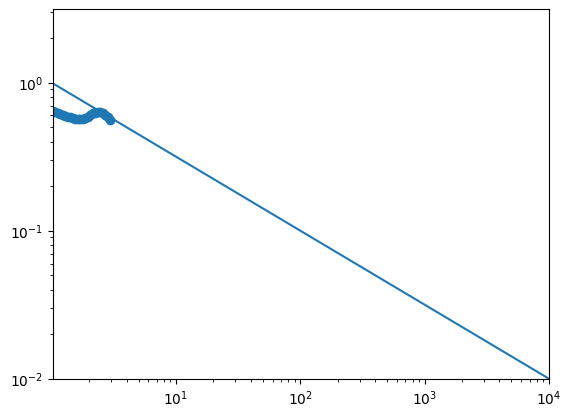

 12%|█▏        | 24/200 [00:20<02:24,  1.22it/s]

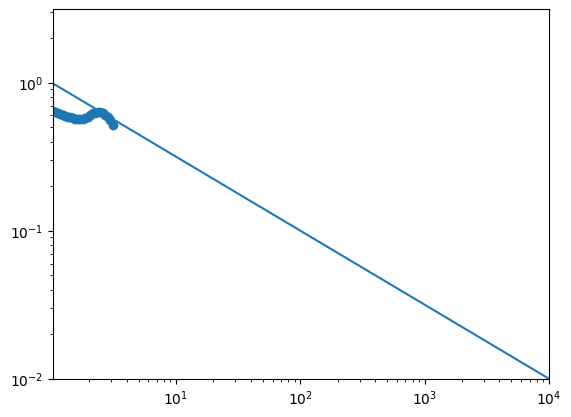

 12%|█▎        | 25/200 [00:21<02:24,  1.21it/s]

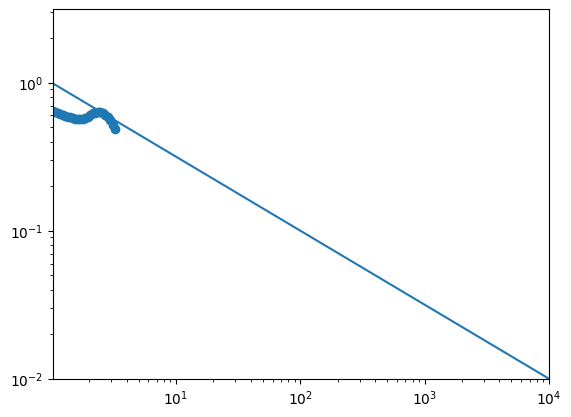

 13%|█▎        | 26/200 [00:22<02:22,  1.22it/s]

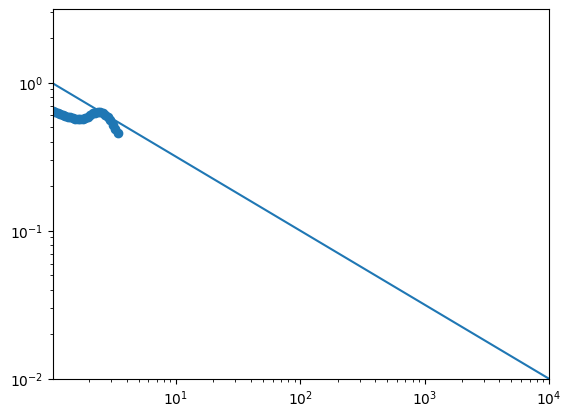

 14%|█▎        | 27/200 [00:23<02:20,  1.23it/s]

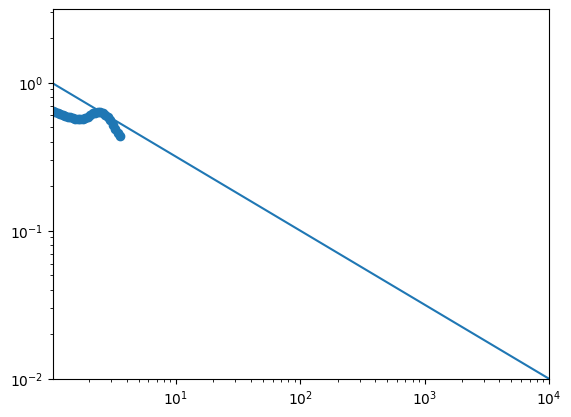

 14%|█▍        | 28/200 [00:24<02:32,  1.13it/s]

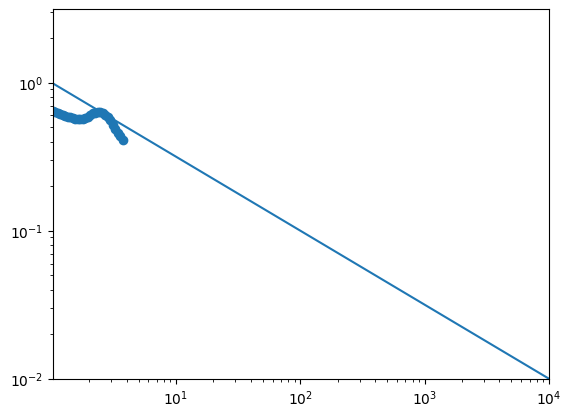

 14%|█▍        | 29/200 [00:24<02:27,  1.16it/s]

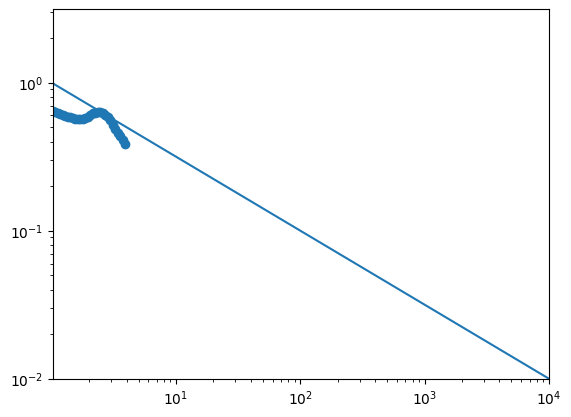

 15%|█▌        | 30/200 [00:25<02:25,  1.16it/s]

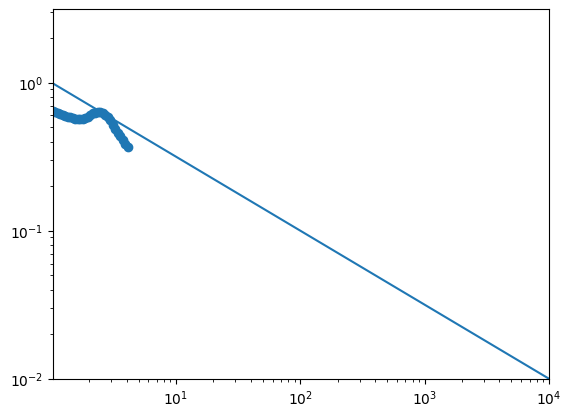

 16%|█▌        | 31/200 [00:26<02:24,  1.17it/s]

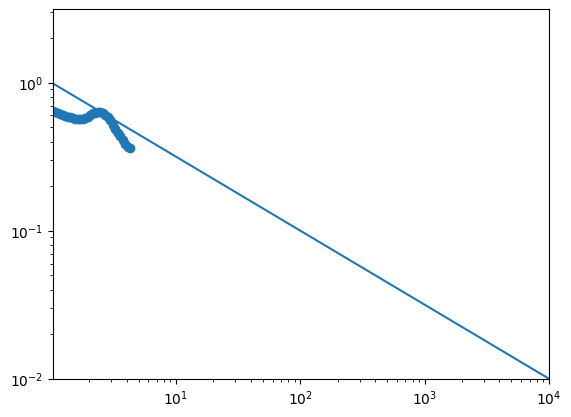

 16%|█▌        | 32/200 [00:27<02:21,  1.19it/s]

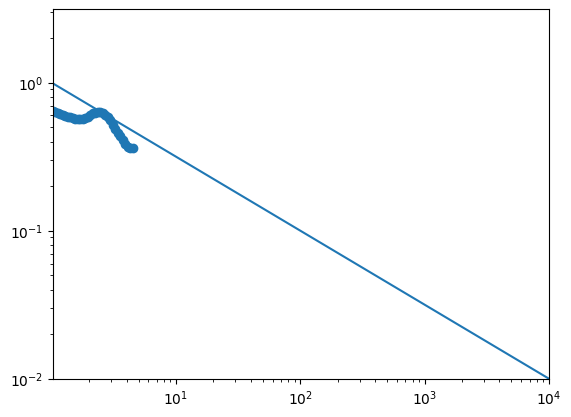

 16%|█▋        | 33/200 [00:28<02:19,  1.20it/s]

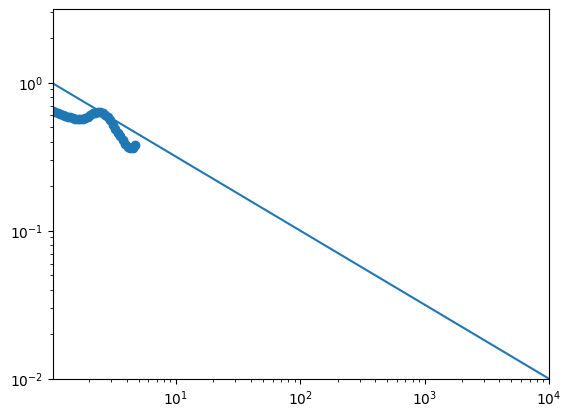

 17%|█▋        | 34/200 [00:29<02:17,  1.21it/s]

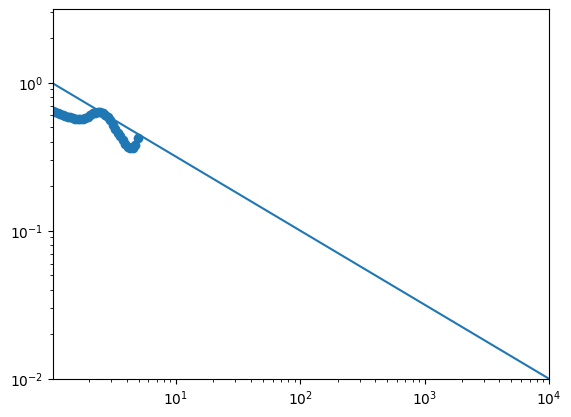

 18%|█▊        | 35/200 [00:29<02:16,  1.21it/s]

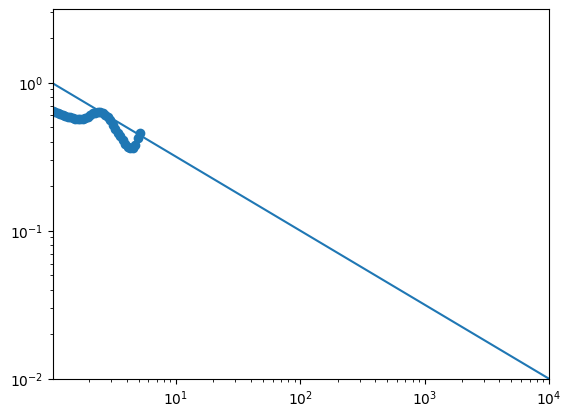

 18%|█▊        | 36/200 [00:30<02:14,  1.22it/s]

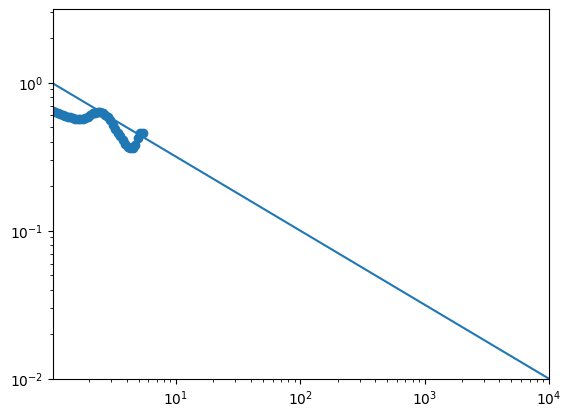

 18%|█▊        | 37/200 [00:31<02:13,  1.22it/s]

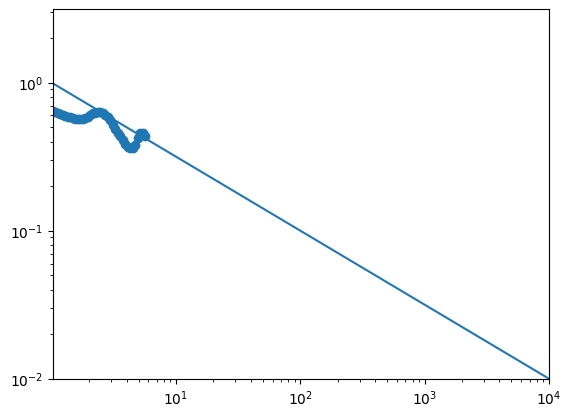

 19%|█▉        | 38/200 [00:32<02:12,  1.23it/s]

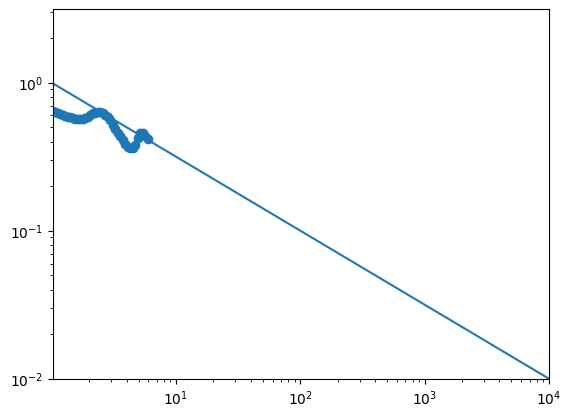

 20%|█▉        | 39/200 [00:33<02:11,  1.23it/s]

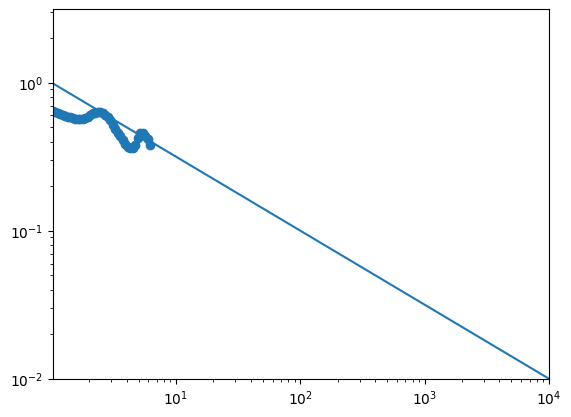

 20%|██        | 40/200 [00:33<02:10,  1.23it/s]

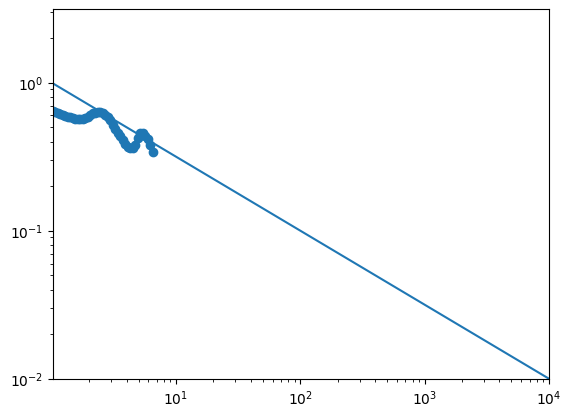

 20%|██        | 41/200 [00:34<02:09,  1.23it/s]

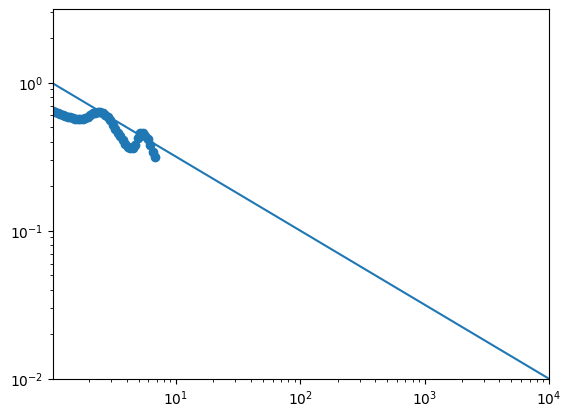

 21%|██        | 42/200 [00:35<02:08,  1.23it/s]

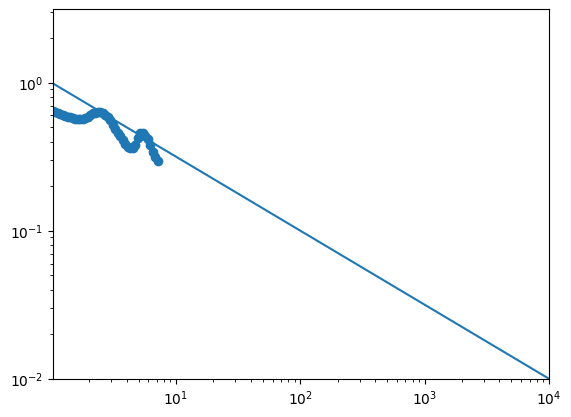

 22%|██▏       | 43/200 [00:36<02:09,  1.21it/s]

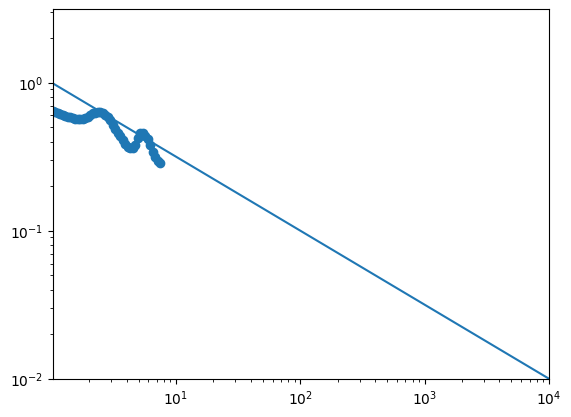

 22%|██▏       | 44/200 [00:37<02:08,  1.21it/s]

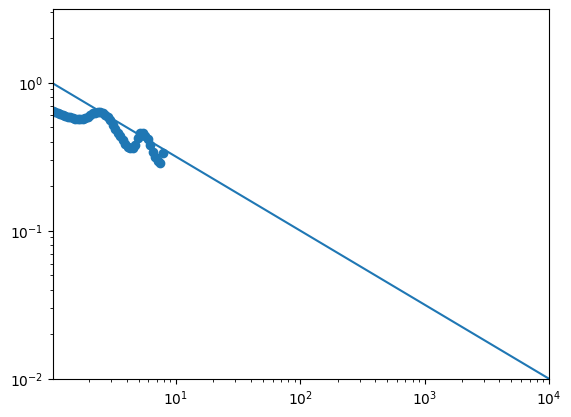

 22%|██▎       | 45/200 [00:38<02:19,  1.11it/s]

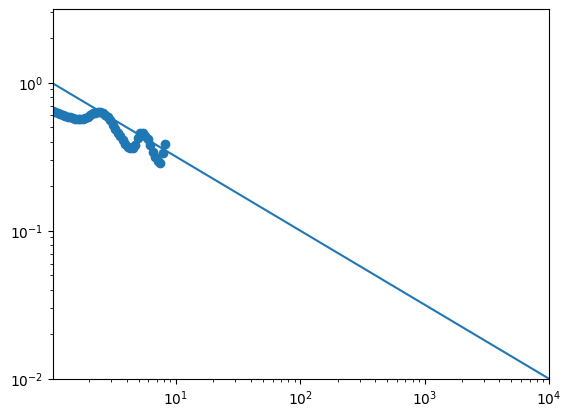

 23%|██▎       | 46/200 [00:39<02:15,  1.14it/s]

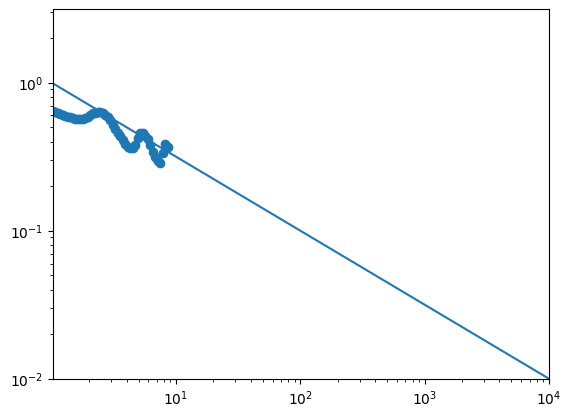

 24%|██▎       | 47/200 [00:39<02:11,  1.16it/s]

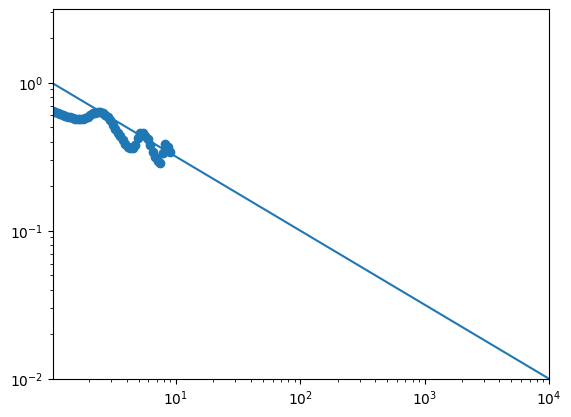

 24%|██▍       | 48/200 [00:40<02:08,  1.18it/s]

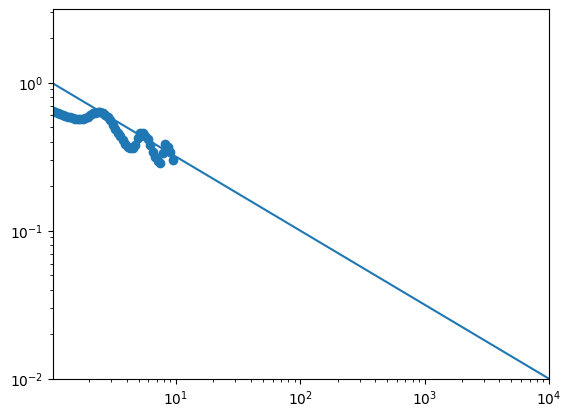

 24%|██▍       | 49/200 [00:41<02:06,  1.19it/s]

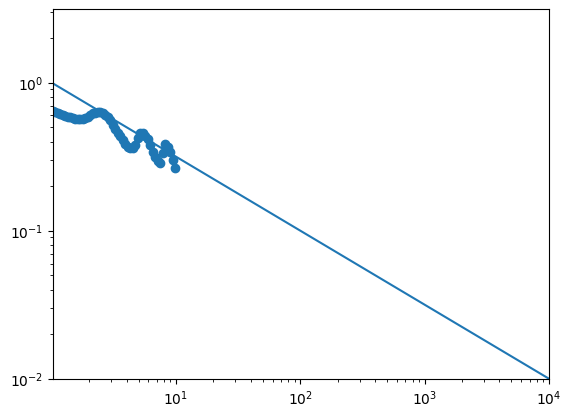

 25%|██▌       | 50/200 [00:42<02:04,  1.20it/s]

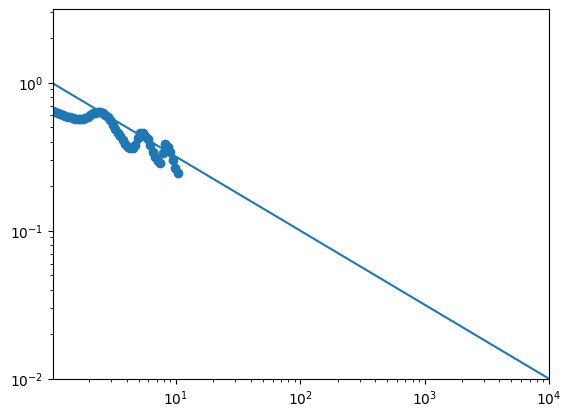

 26%|██▌       | 51/200 [00:43<02:03,  1.21it/s]

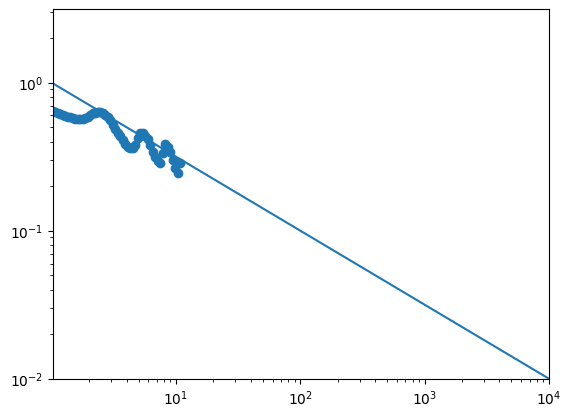

 26%|██▌       | 52/200 [00:44<02:02,  1.21it/s]

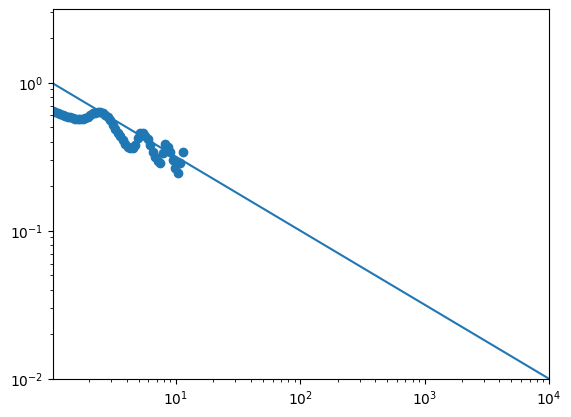

 26%|██▋       | 53/200 [00:44<02:01,  1.21it/s]

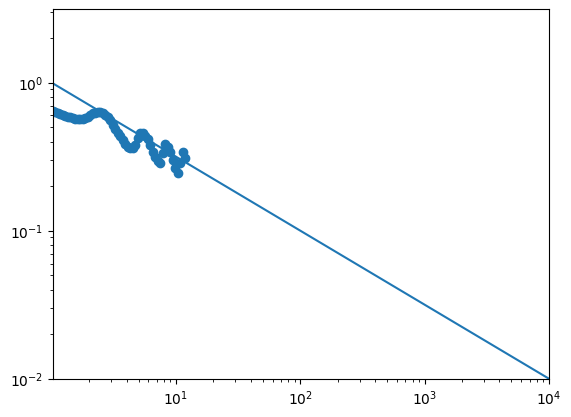

 27%|██▋       | 54/200 [00:45<02:01,  1.21it/s]

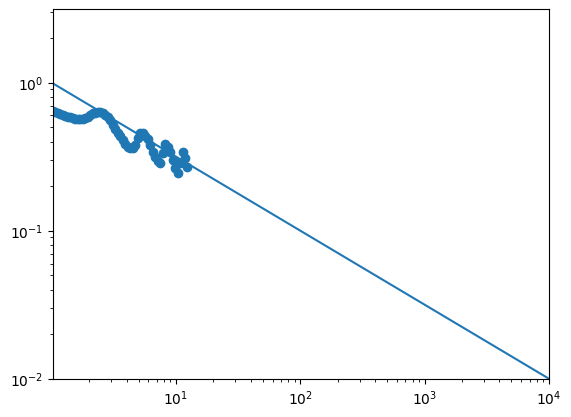

 28%|██▊       | 55/200 [00:46<01:59,  1.21it/s]

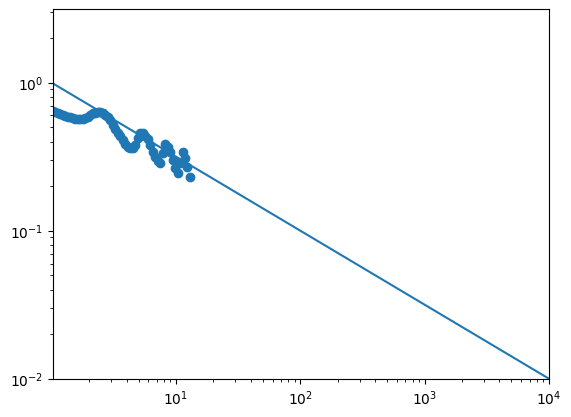

 28%|██▊       | 56/200 [00:47<01:58,  1.21it/s]

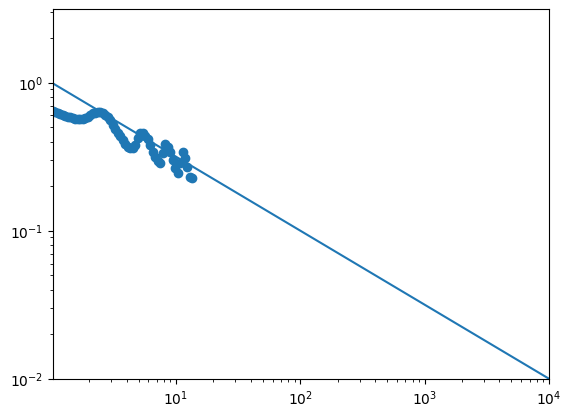

 28%|██▊       | 57/200 [00:48<01:57,  1.22it/s]

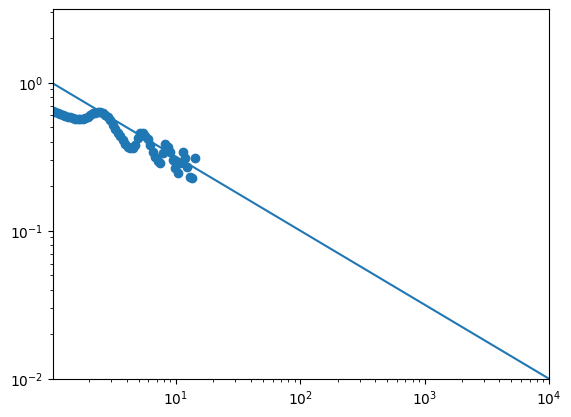

 29%|██▉       | 58/200 [00:48<01:56,  1.22it/s]

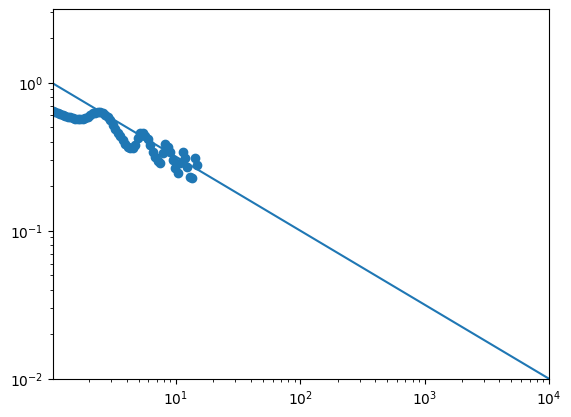

 30%|██▉       | 59/200 [00:49<01:55,  1.22it/s]

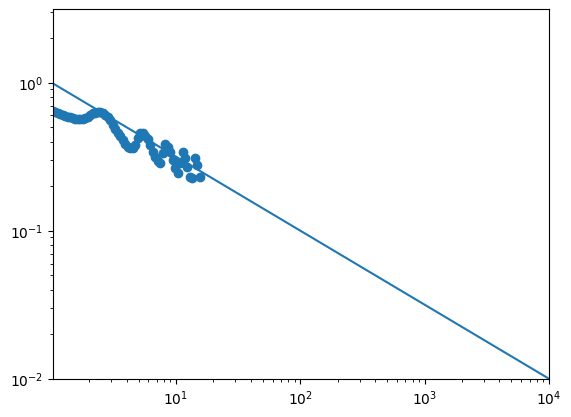

 30%|███       | 60/200 [00:50<01:55,  1.22it/s]

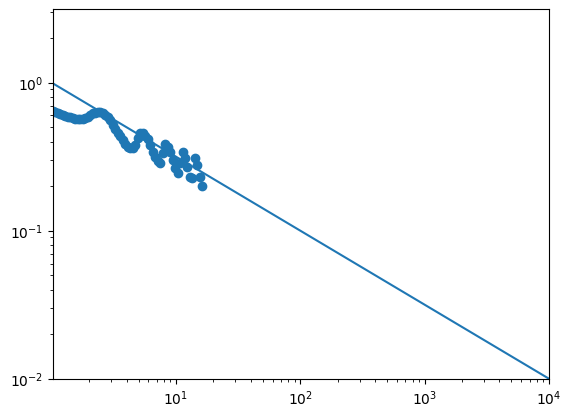

 30%|███       | 61/200 [00:51<02:08,  1.08it/s]

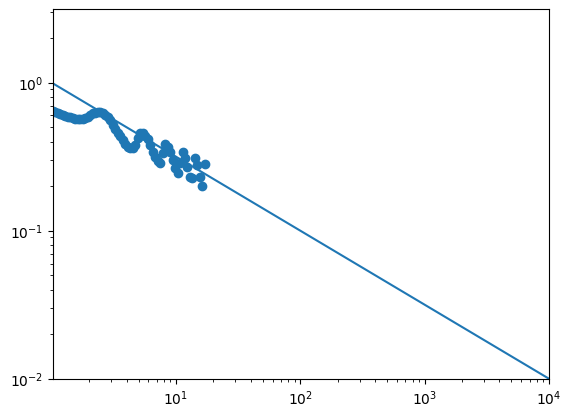

 31%|███       | 62/200 [00:52<02:08,  1.08it/s]

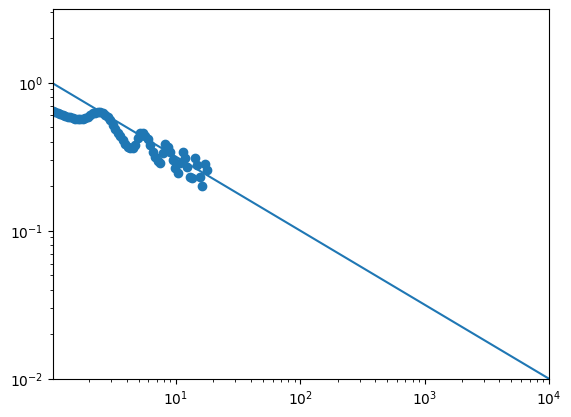

 32%|███▏      | 63/200 [00:53<02:09,  1.06it/s]

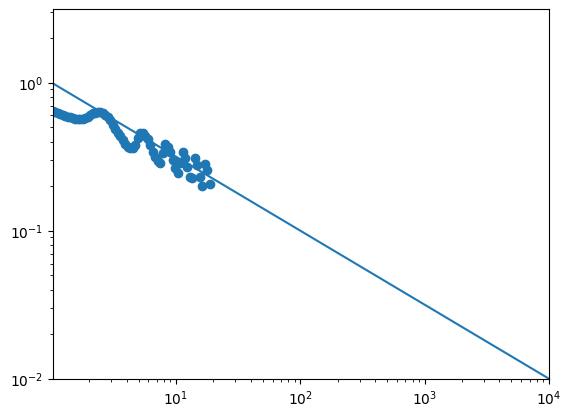

 32%|███▏      | 64/200 [00:54<02:10,  1.04it/s]

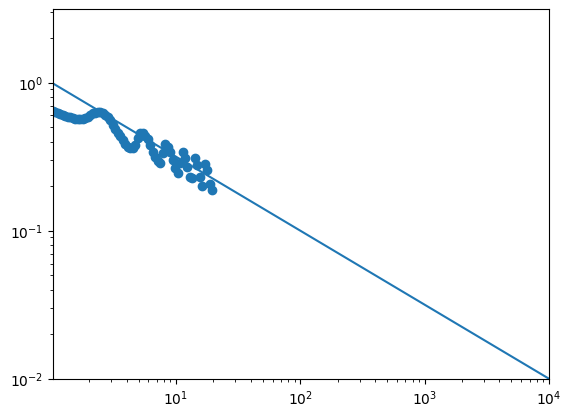

 32%|███▎      | 65/200 [00:55<02:14,  1.01it/s]

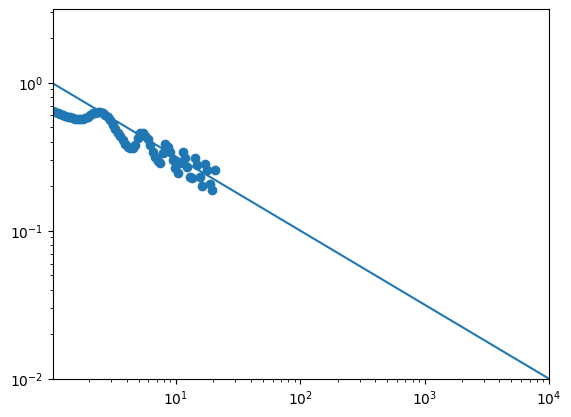

 33%|███▎      | 66/200 [00:56<02:15,  1.01s/it]

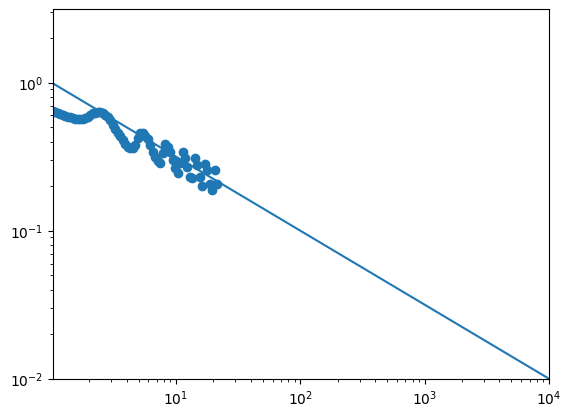

 34%|███▎      | 67/200 [00:57<02:17,  1.03s/it]

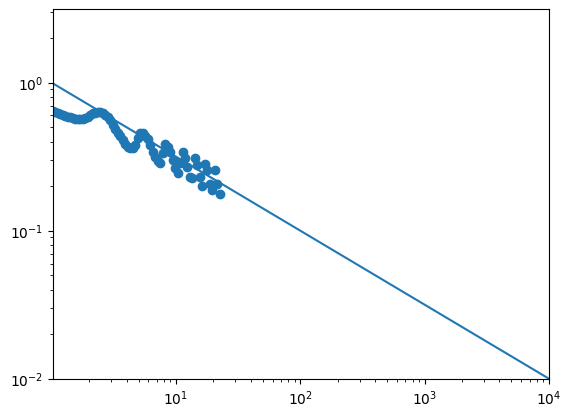

 34%|███▍      | 68/200 [00:58<02:19,  1.05s/it]

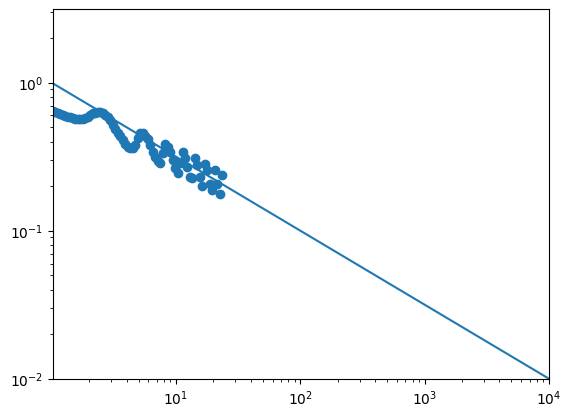

 34%|███▍      | 69/200 [01:00<02:20,  1.07s/it]

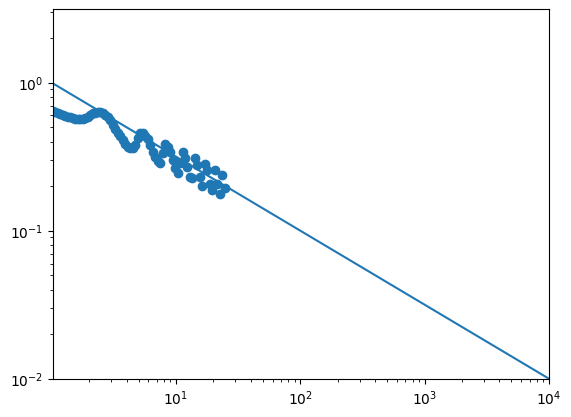

 35%|███▌      | 70/200 [01:01<02:22,  1.10s/it]

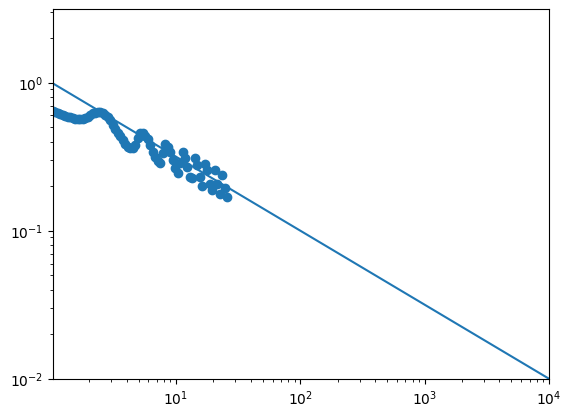

 36%|███▌      | 71/200 [01:02<02:22,  1.11s/it]

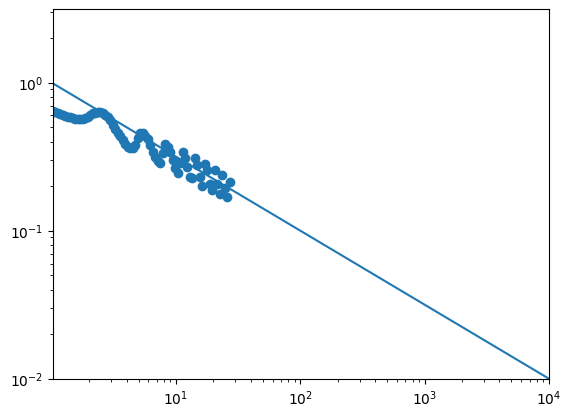

 36%|███▌      | 72/200 [01:03<02:25,  1.14s/it]

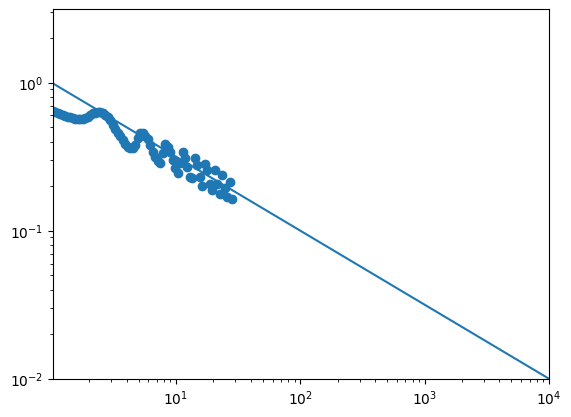

 36%|███▋      | 73/200 [01:04<02:28,  1.17s/it]

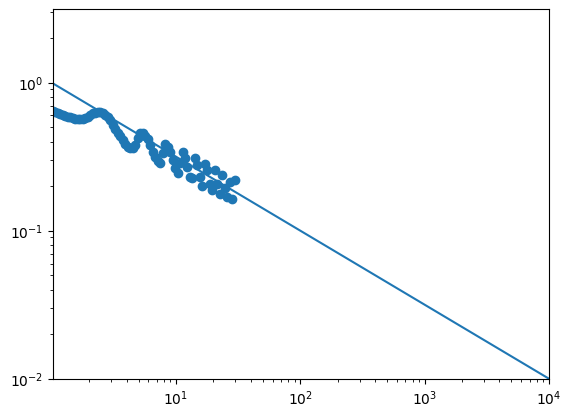

 37%|███▋      | 74/200 [01:06<02:30,  1.19s/it]

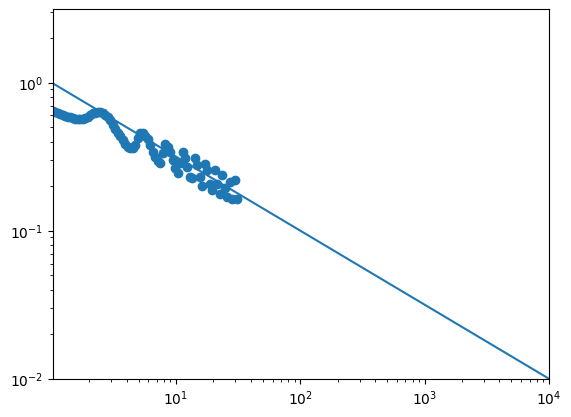

 38%|███▊      | 75/200 [01:07<02:32,  1.22s/it]

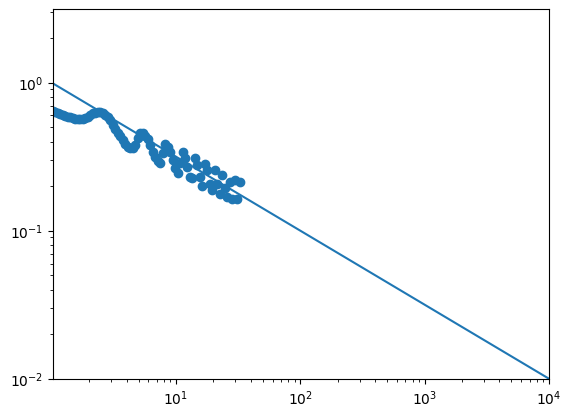

 38%|███▊      | 76/200 [01:08<02:33,  1.23s/it]

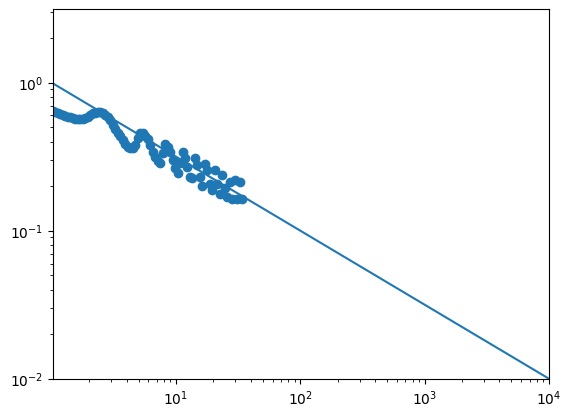

 38%|███▊      | 77/200 [01:10<02:43,  1.33s/it]

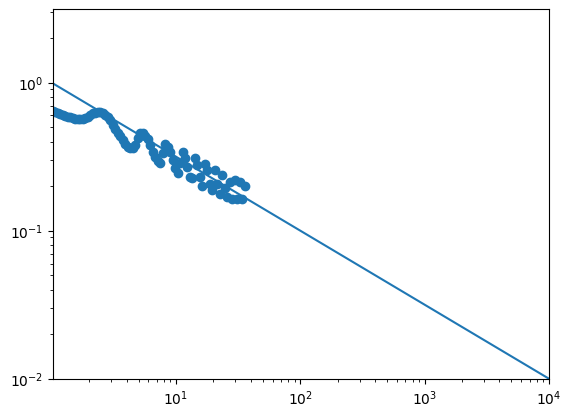

 39%|███▉      | 78/200 [01:11<02:41,  1.33s/it]

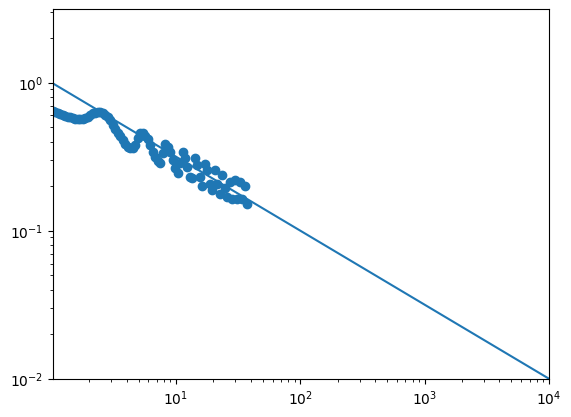

 40%|███▉      | 79/200 [01:12<02:39,  1.32s/it]

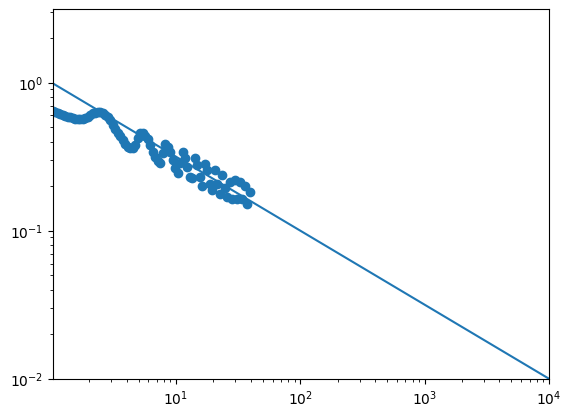

 40%|████      | 80/200 [01:14<02:36,  1.31s/it]

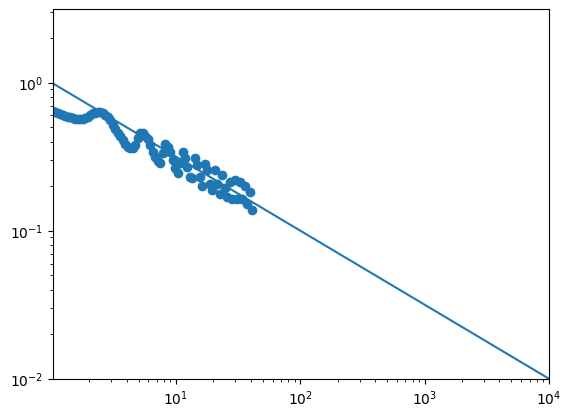

 40%|████      | 81/200 [01:15<02:33,  1.29s/it]

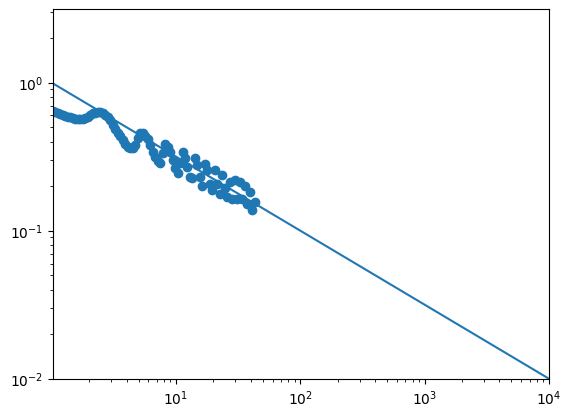

 41%|████      | 82/200 [01:16<02:30,  1.28s/it]

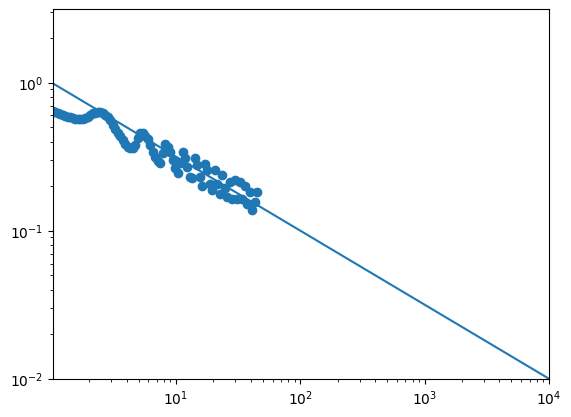

 42%|████▏     | 83/200 [01:17<02:28,  1.27s/it]

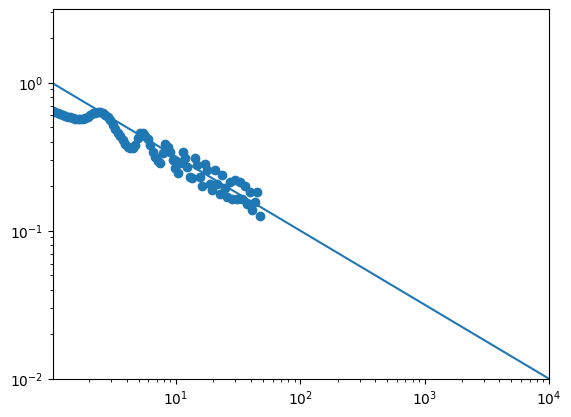

 42%|████▏     | 84/200 [01:19<02:27,  1.27s/it]

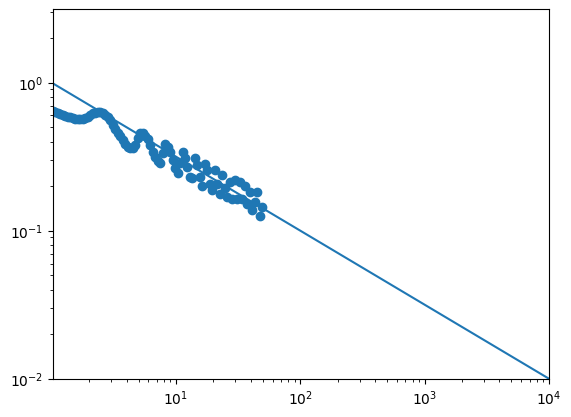

 42%|████▎     | 85/200 [01:20<02:27,  1.28s/it]

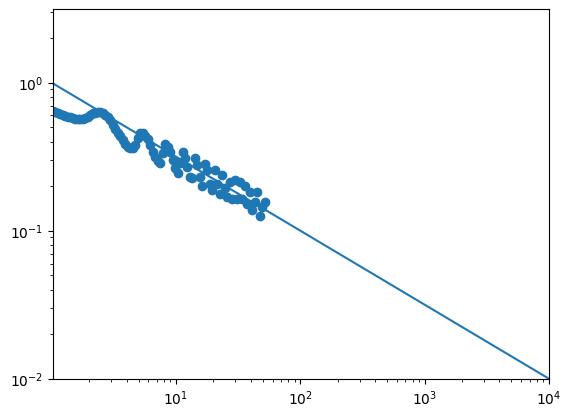

 43%|████▎     | 86/200 [01:21<02:26,  1.29s/it]

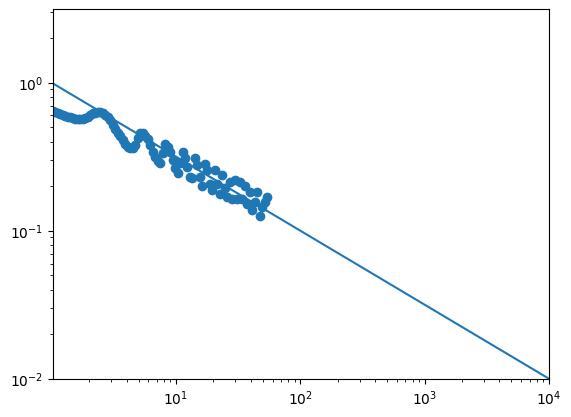

 44%|████▎     | 87/200 [01:23<02:26,  1.30s/it]

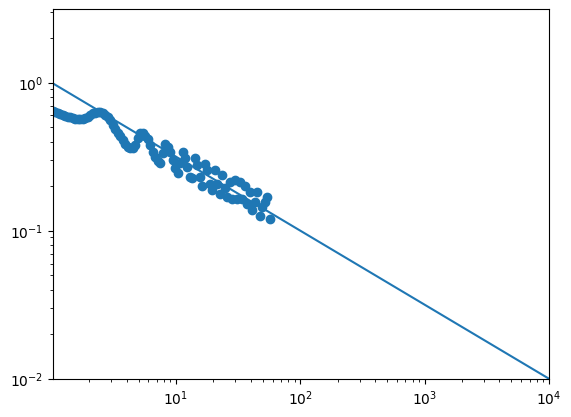

 44%|████▍     | 88/200 [01:24<02:25,  1.30s/it]

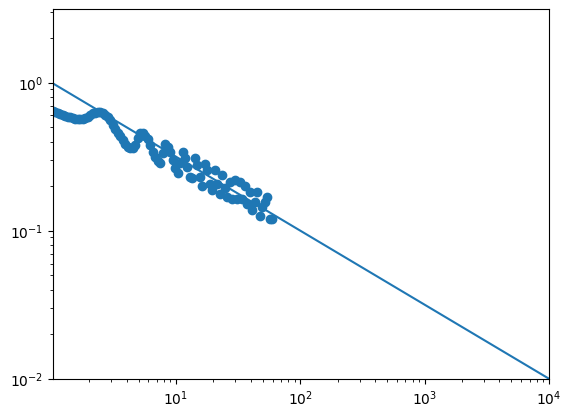

 44%|████▍     | 89/200 [01:25<02:24,  1.30s/it]

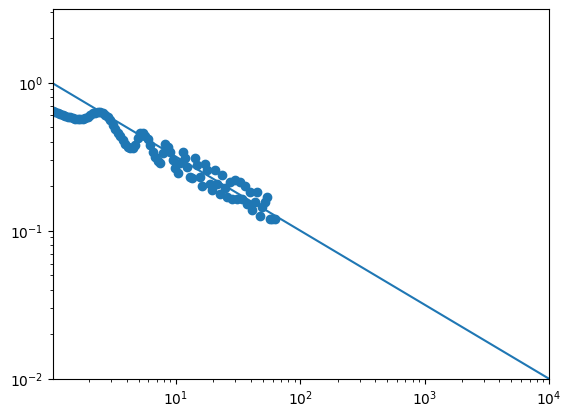

 45%|████▌     | 90/200 [01:26<02:23,  1.30s/it]

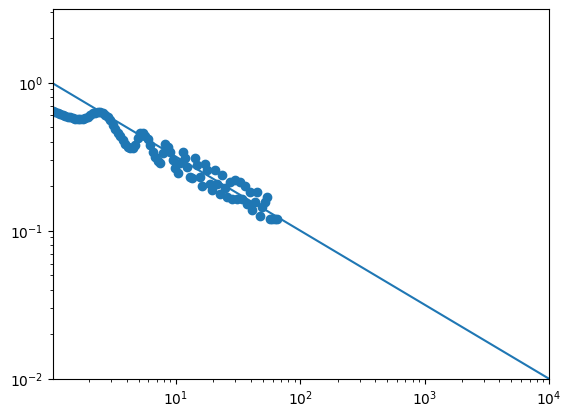

 46%|████▌     | 91/200 [01:28<02:23,  1.31s/it]

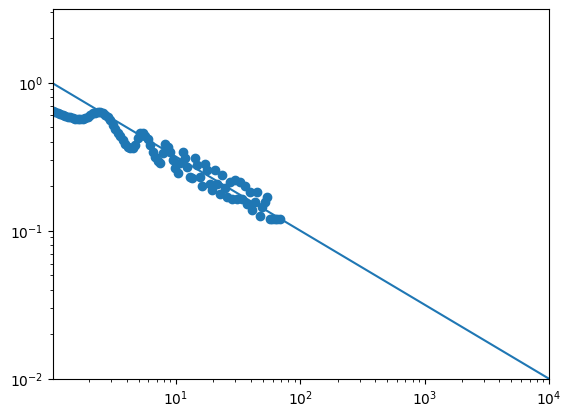

 46%|████▌     | 92/200 [01:29<02:23,  1.33s/it]

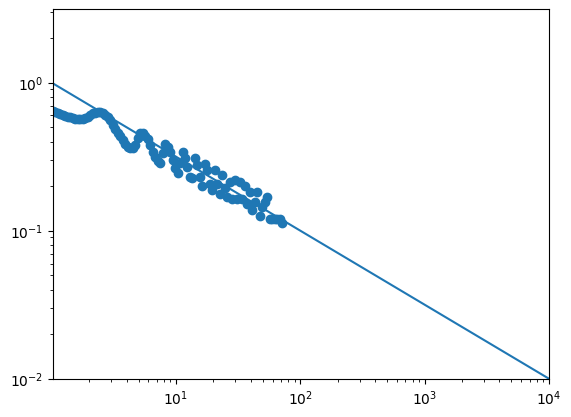

 46%|████▋     | 93/200 [01:31<02:22,  1.33s/it]

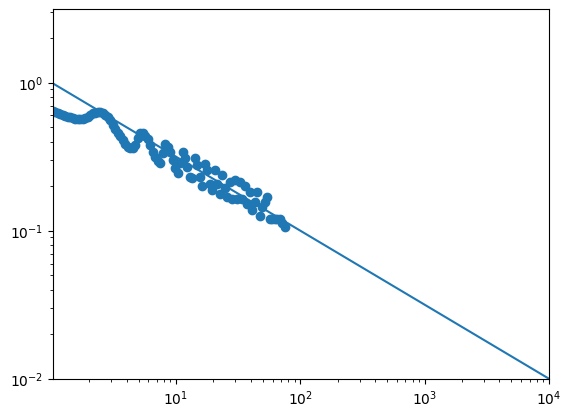

 47%|████▋     | 94/200 [01:32<02:29,  1.41s/it]

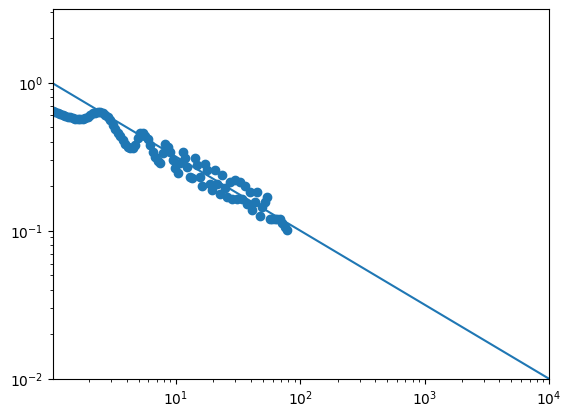

 48%|████▊     | 95/200 [01:33<02:26,  1.40s/it]

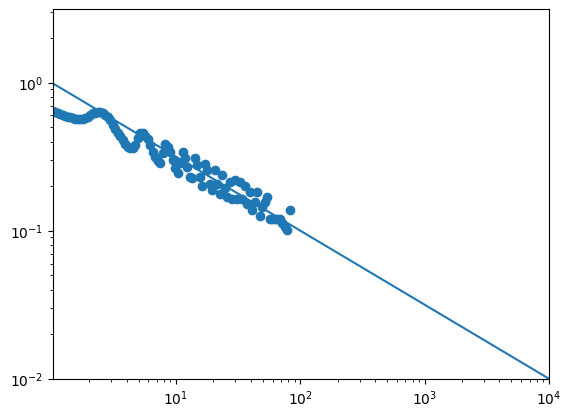

 48%|████▊     | 96/200 [01:35<02:25,  1.40s/it]

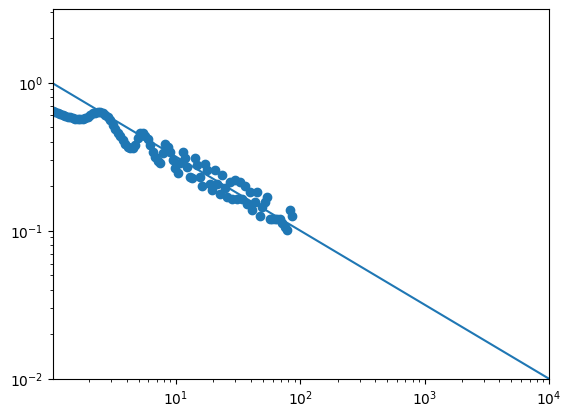

 48%|████▊     | 97/200 [01:36<02:25,  1.42s/it]

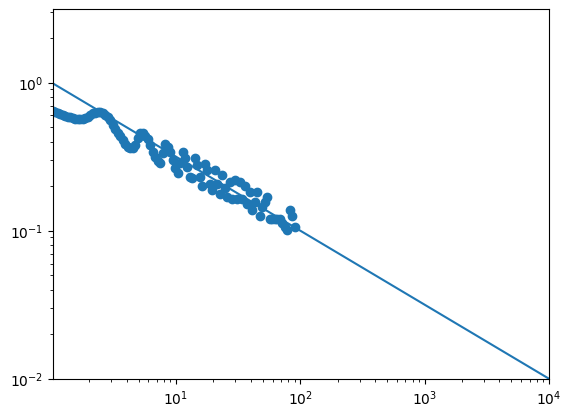

 49%|████▉     | 98/200 [01:38<02:25,  1.42s/it]

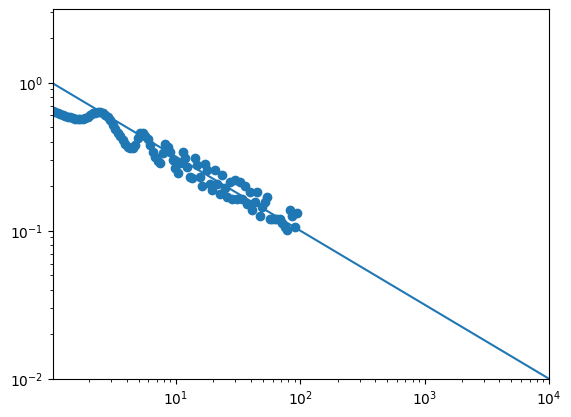

 50%|████▉     | 99/200 [01:39<02:23,  1.42s/it]

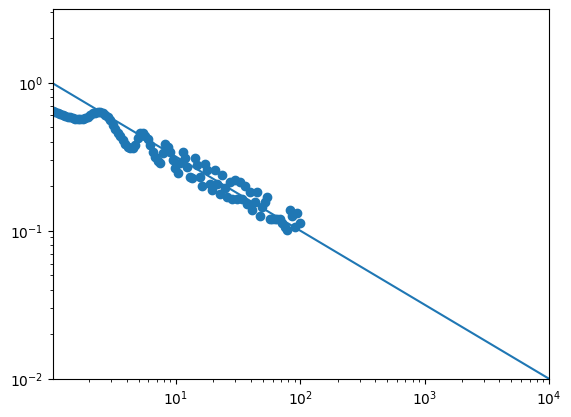

 50%|█████     | 100/200 [01:41<02:22,  1.43s/it]

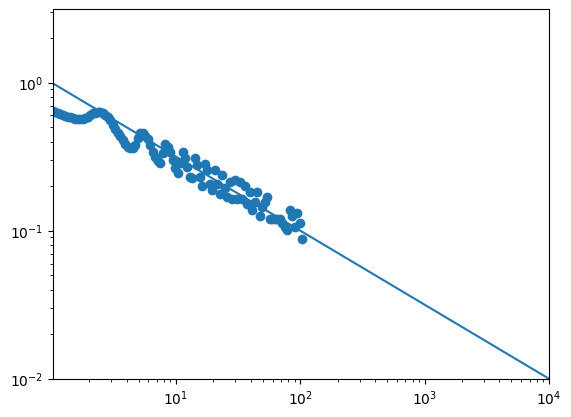

 50%|█████     | 101/200 [01:42<02:22,  1.44s/it]

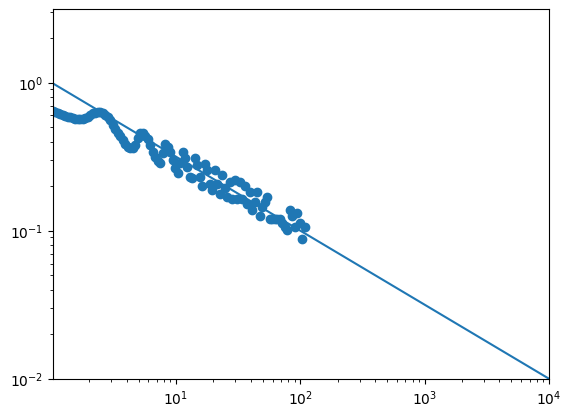

 51%|█████     | 102/200 [01:44<02:22,  1.45s/it]

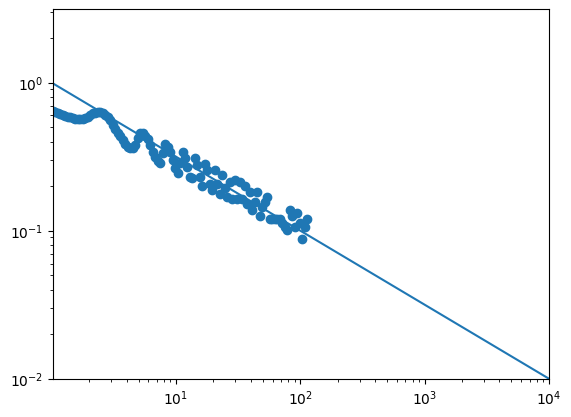

 52%|█████▏    | 103/200 [01:45<02:22,  1.47s/it]

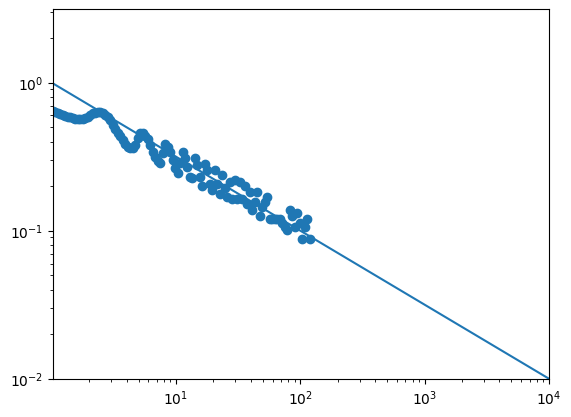

 52%|█████▏    | 104/200 [01:47<02:22,  1.48s/it]

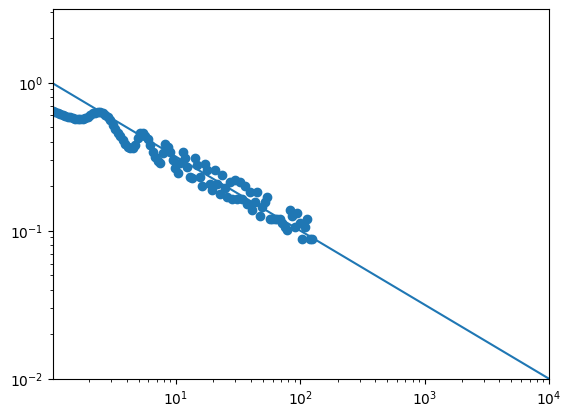

 52%|█████▎    | 105/200 [01:48<02:22,  1.50s/it]

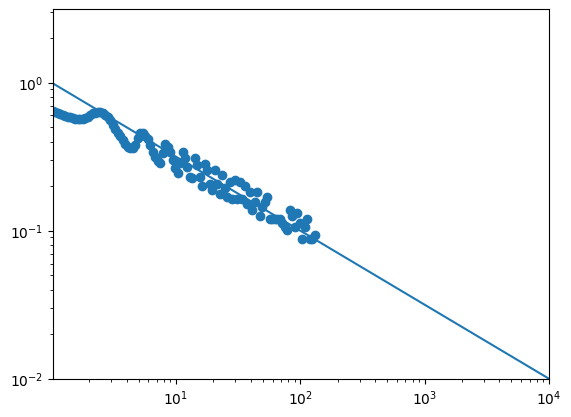

 53%|█████▎    | 106/200 [01:50<02:22,  1.51s/it]

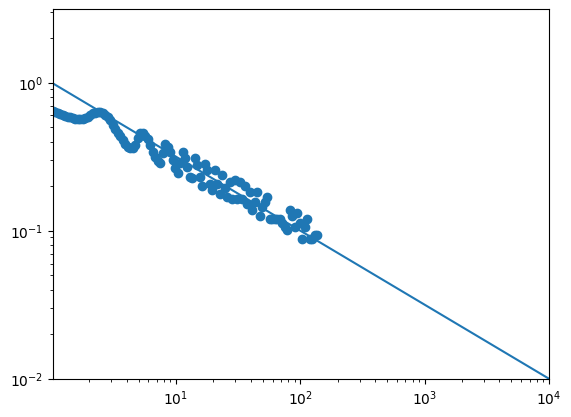

 54%|█████▎    | 107/200 [01:51<02:22,  1.53s/it]

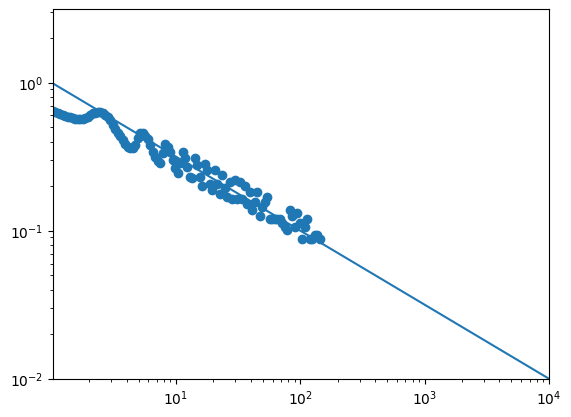

 54%|█████▍    | 108/200 [01:53<02:22,  1.55s/it]

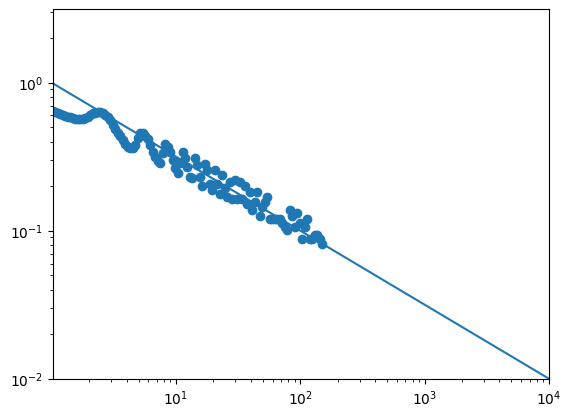

 55%|█████▍    | 109/200 [01:54<02:20,  1.54s/it]

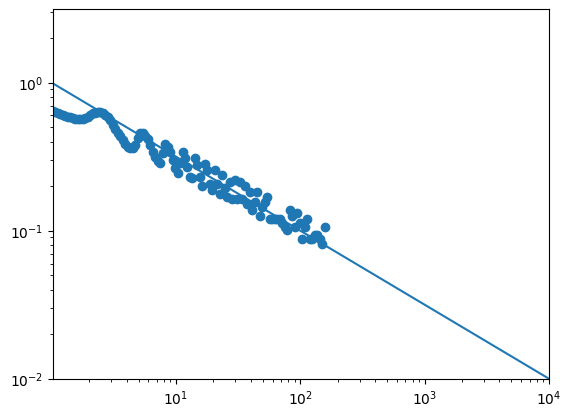

 55%|█████▌    | 110/200 [01:56<02:22,  1.59s/it]

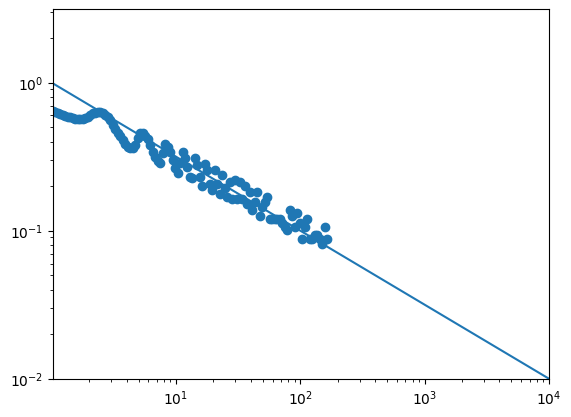

 56%|█████▌    | 111/200 [01:58<02:17,  1.54s/it]

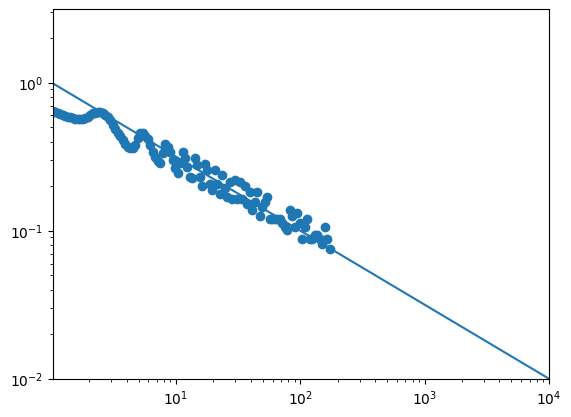

 56%|█████▌    | 112/200 [01:59<02:12,  1.51s/it]

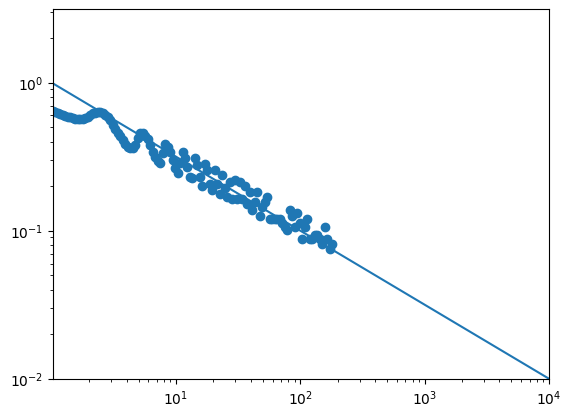

 56%|█████▋    | 113/200 [02:00<02:08,  1.47s/it]

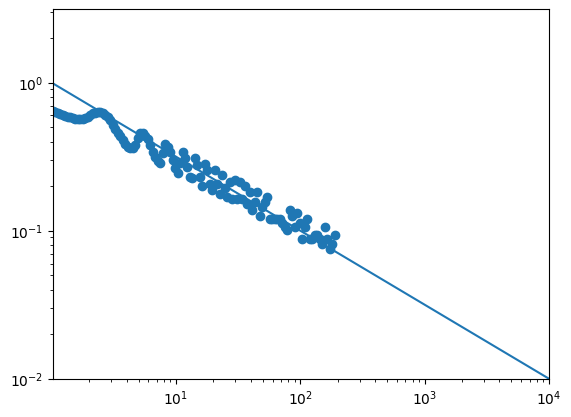

 57%|█████▋    | 114/200 [02:02<02:03,  1.44s/it]

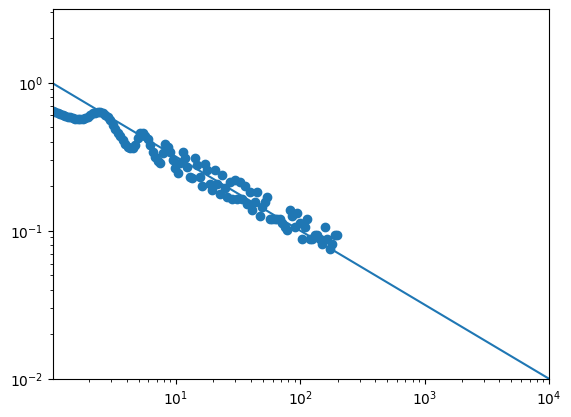

 57%|█████▊    | 115/200 [02:03<01:59,  1.41s/it]

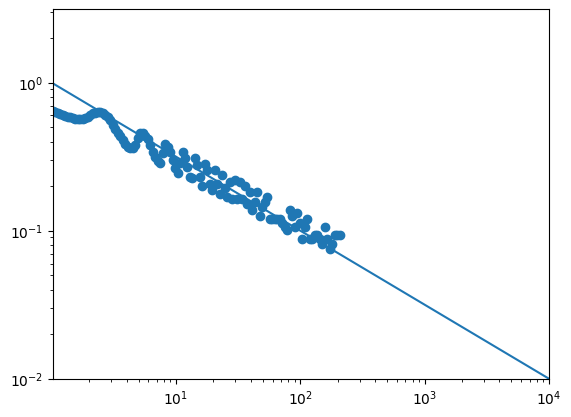

 58%|█████▊    | 116/200 [02:04<01:56,  1.39s/it]

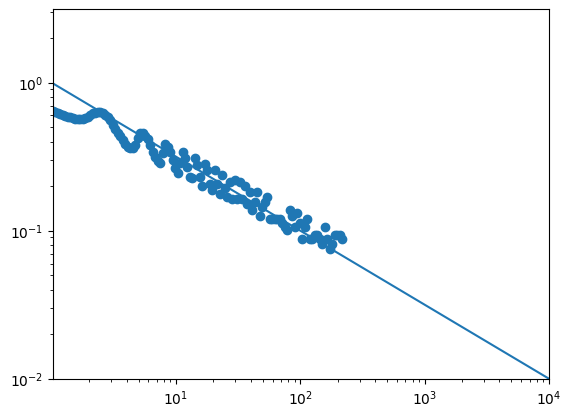

 58%|█████▊    | 117/200 [02:06<01:53,  1.37s/it]

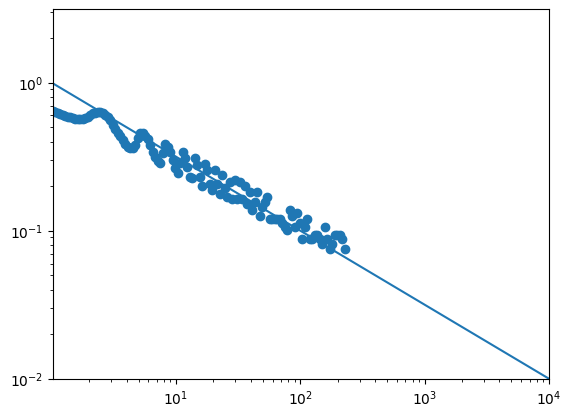

 59%|█████▉    | 118/200 [02:07<01:51,  1.35s/it]

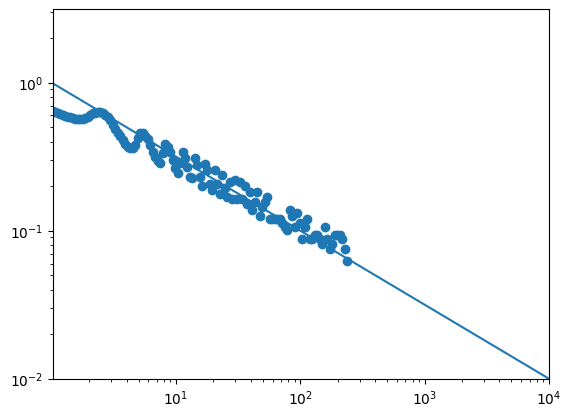

 60%|█████▉    | 119/200 [02:08<01:48,  1.34s/it]

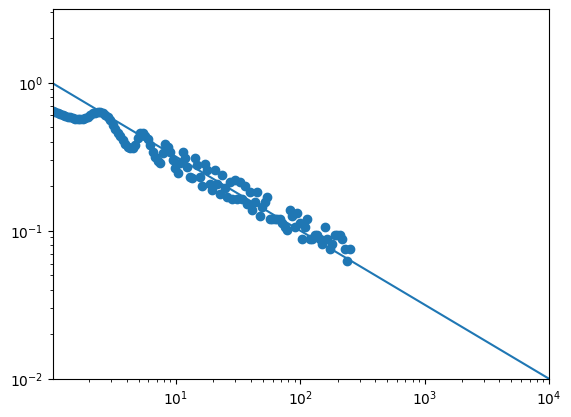

 60%|██████    | 120/200 [02:10<01:46,  1.33s/it]

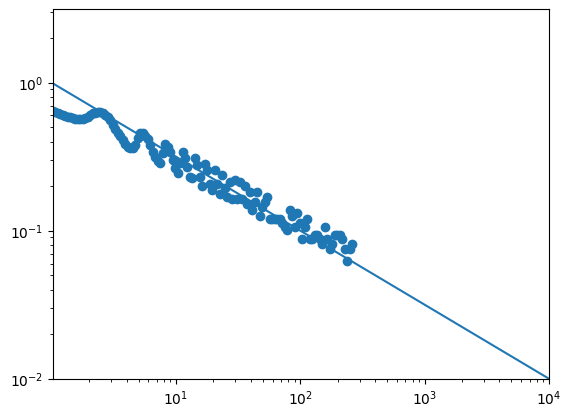

 60%|██████    | 121/200 [02:11<01:44,  1.32s/it]

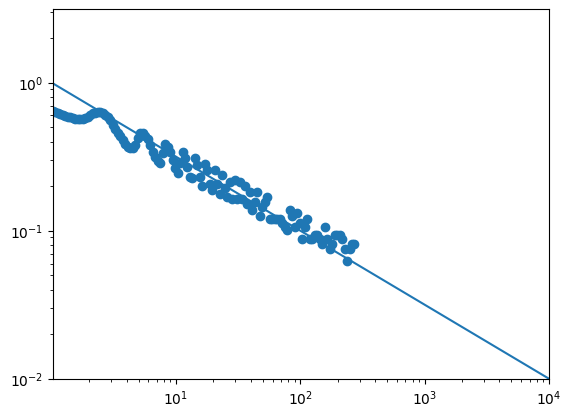

 61%|██████    | 122/200 [02:12<01:42,  1.31s/it]

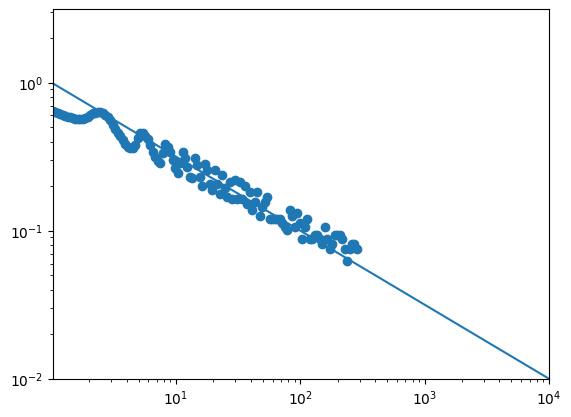

 62%|██████▏   | 123/200 [02:14<01:40,  1.31s/it]

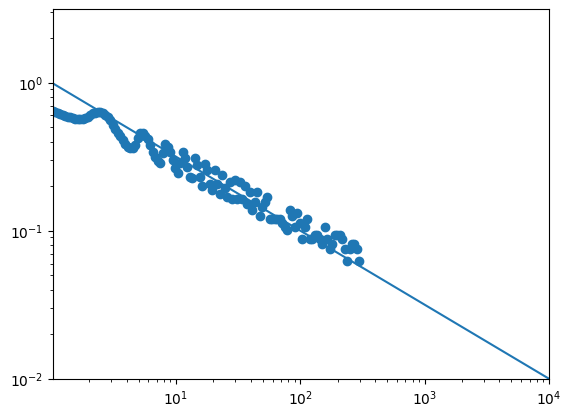

 62%|██████▏   | 124/200 [02:15<01:39,  1.30s/it]

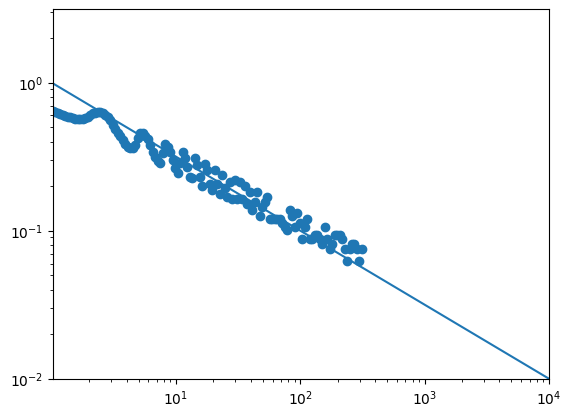

 62%|██████▎   | 125/200 [02:16<01:37,  1.30s/it]

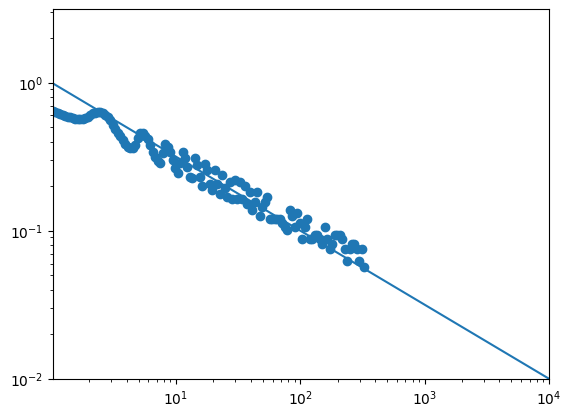

 63%|██████▎   | 126/200 [02:18<01:41,  1.37s/it]

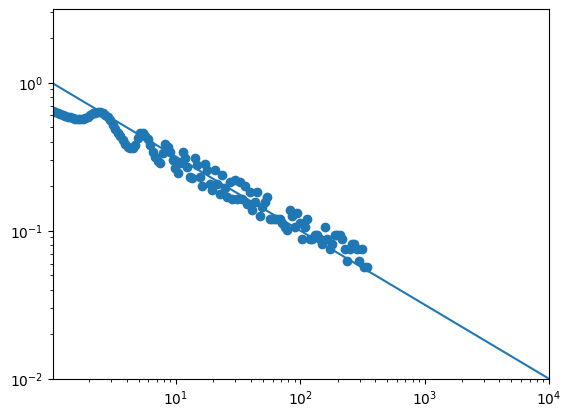

 64%|██████▎   | 127/200 [02:19<01:38,  1.35s/it]

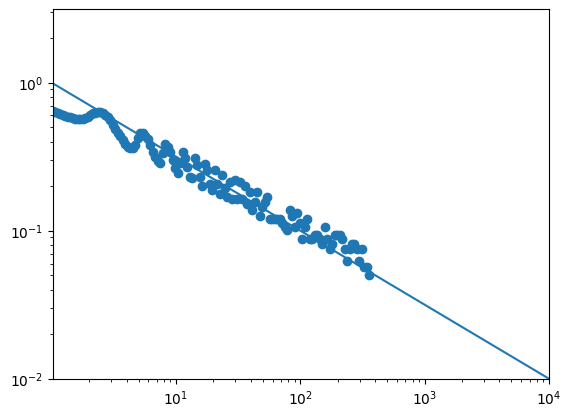

 64%|██████▍   | 128/200 [02:20<01:36,  1.34s/it]

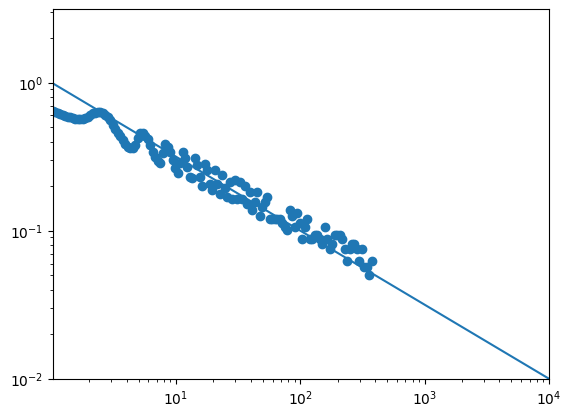

 64%|██████▍   | 129/200 [02:22<01:34,  1.33s/it]

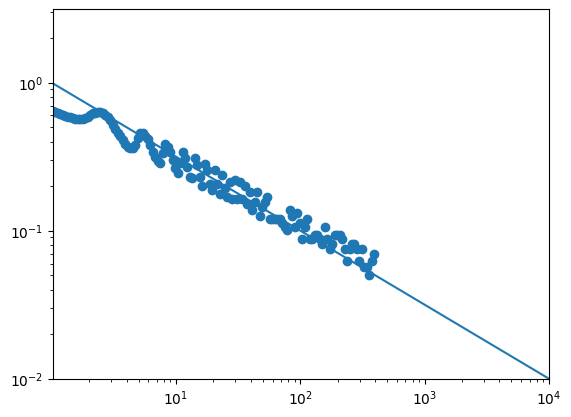

 65%|██████▌   | 130/200 [02:23<01:33,  1.34s/it]

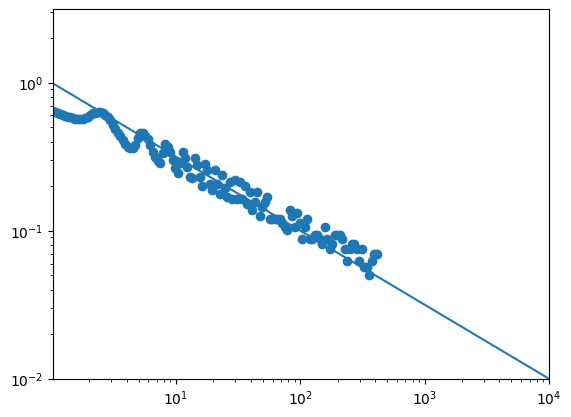

 66%|██████▌   | 131/200 [02:24<01:32,  1.34s/it]

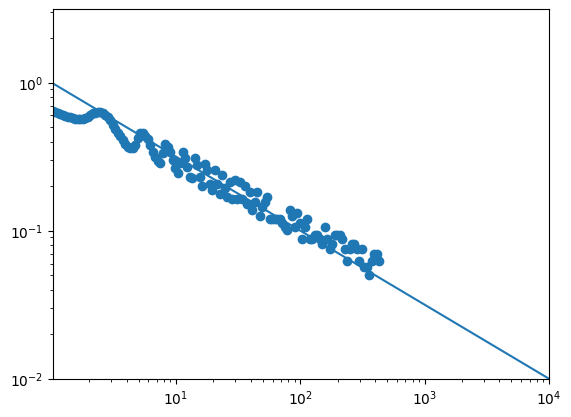

 66%|██████▌   | 132/200 [02:26<01:31,  1.35s/it]

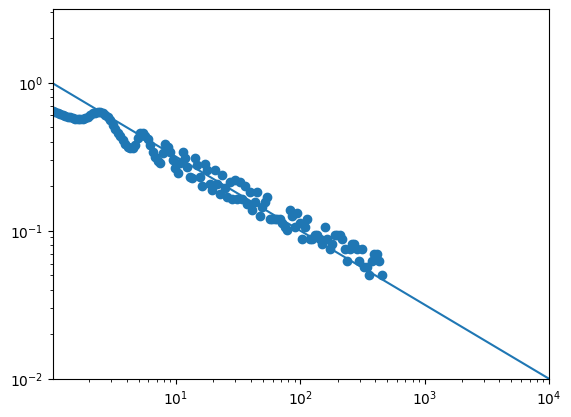

 66%|██████▋   | 133/200 [02:27<01:31,  1.36s/it]

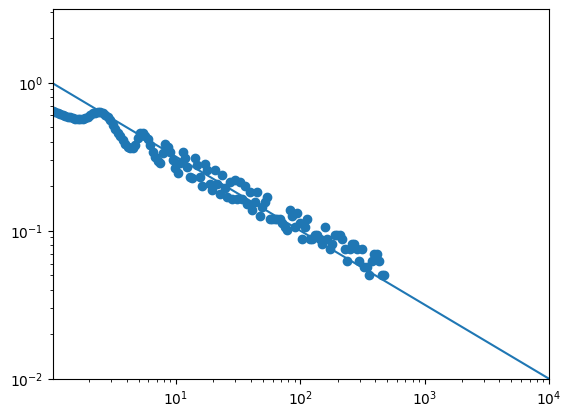

 67%|██████▋   | 134/200 [02:28<01:30,  1.37s/it]

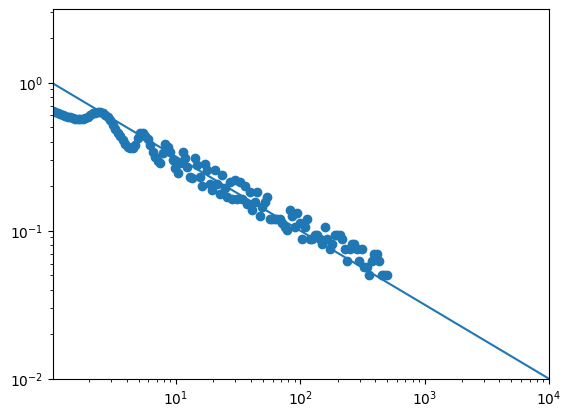

 68%|██████▊   | 135/200 [02:30<01:29,  1.38s/it]

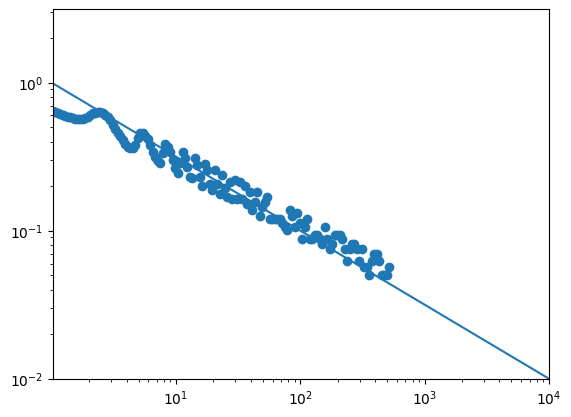

 68%|██████▊   | 136/200 [02:31<01:29,  1.40s/it]

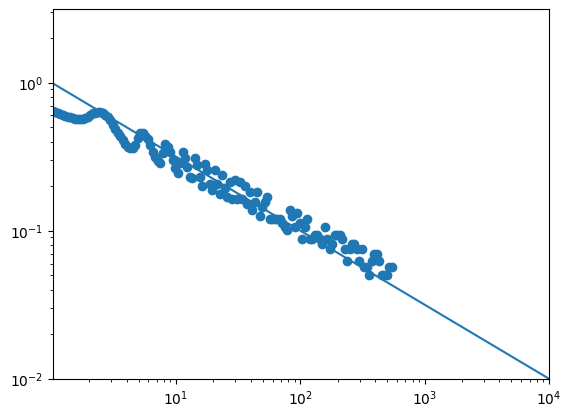

 68%|██████▊   | 137/200 [02:33<01:29,  1.42s/it]

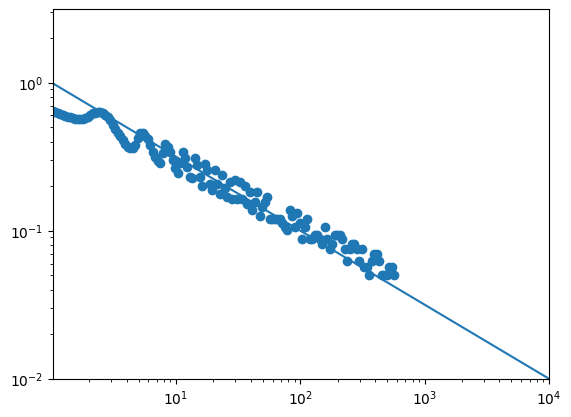

 69%|██████▉   | 138/200 [02:34<01:29,  1.44s/it]

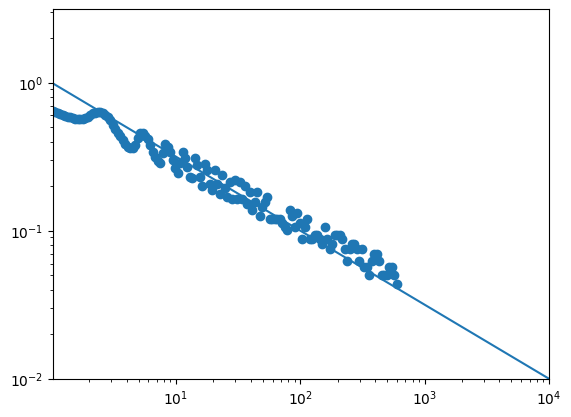

 70%|██████▉   | 139/200 [02:36<01:29,  1.46s/it]

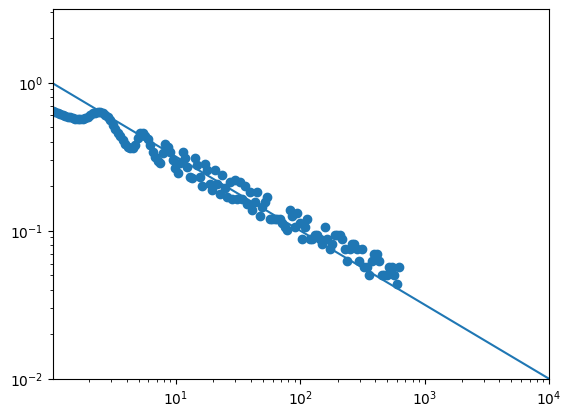

 70%|███████   | 140/200 [02:37<01:29,  1.48s/it]

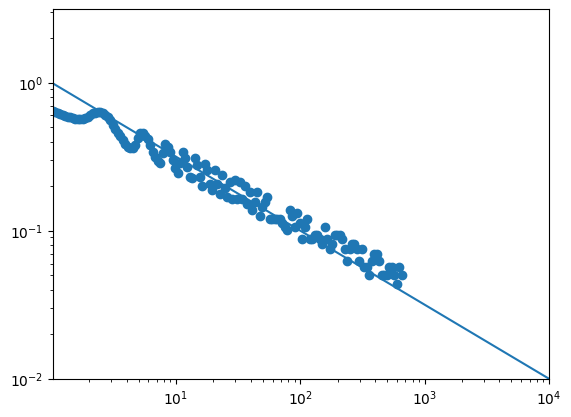

 70%|███████   | 141/200 [02:39<01:29,  1.51s/it]

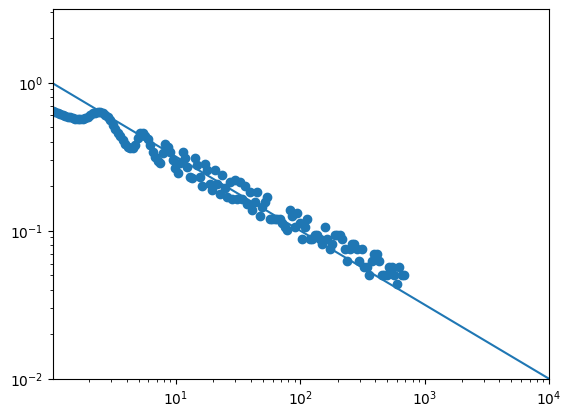

 71%|███████   | 142/200 [02:40<01:30,  1.55s/it]

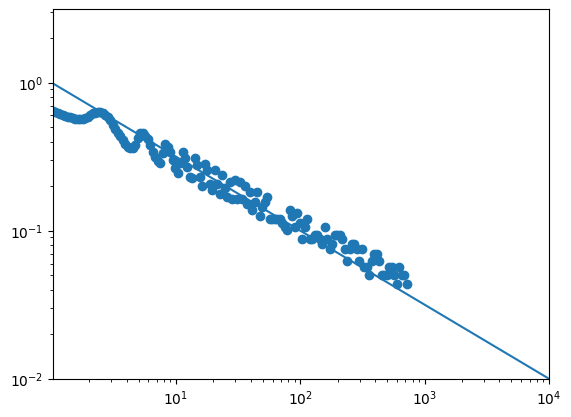

 72%|███████▏  | 143/200 [02:42<01:34,  1.66s/it]

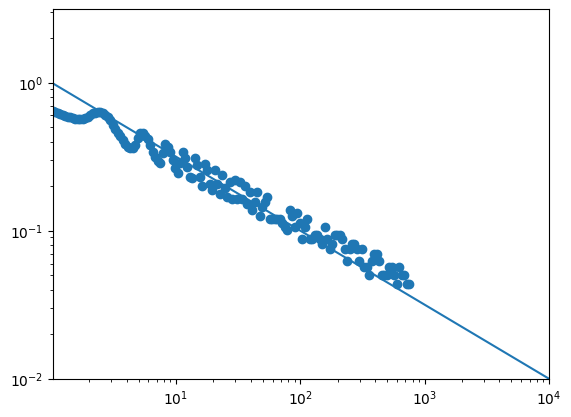

 72%|███████▏  | 144/200 [02:44<01:33,  1.68s/it]

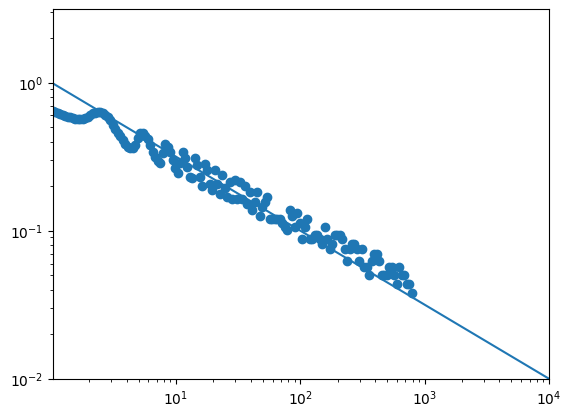

 72%|███████▎  | 145/200 [02:46<01:33,  1.71s/it]

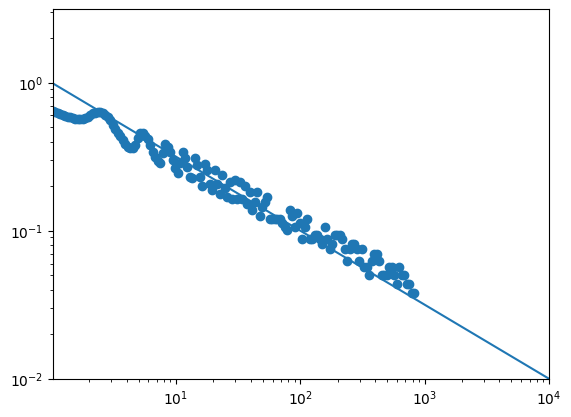

 73%|███████▎  | 146/200 [02:48<01:34,  1.75s/it]

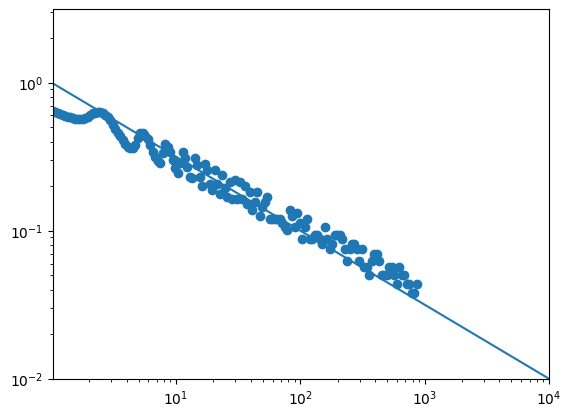

 74%|███████▎  | 147/200 [02:50<01:35,  1.80s/it]

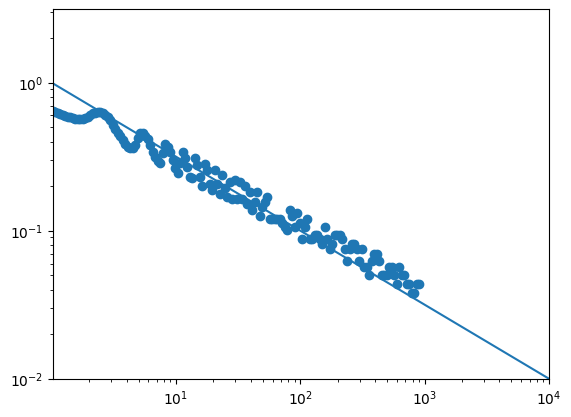

 74%|███████▍  | 148/200 [02:52<01:37,  1.87s/it]

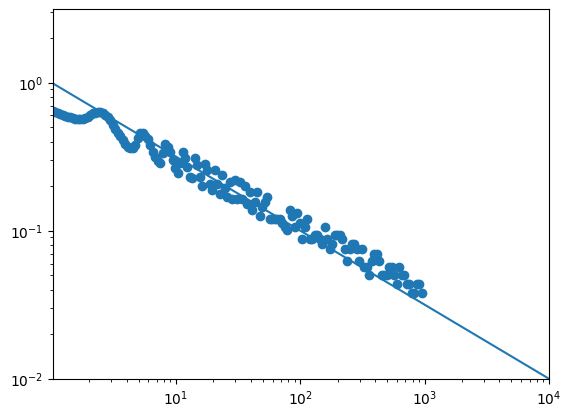

 74%|███████▍  | 149/200 [02:54<01:38,  1.93s/it]

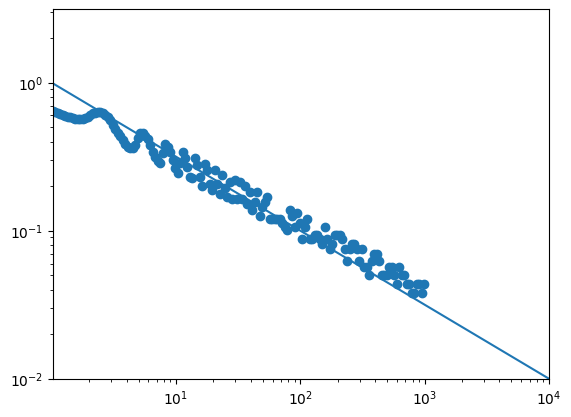

 75%|███████▌  | 150/200 [02:56<01:39,  1.99s/it]

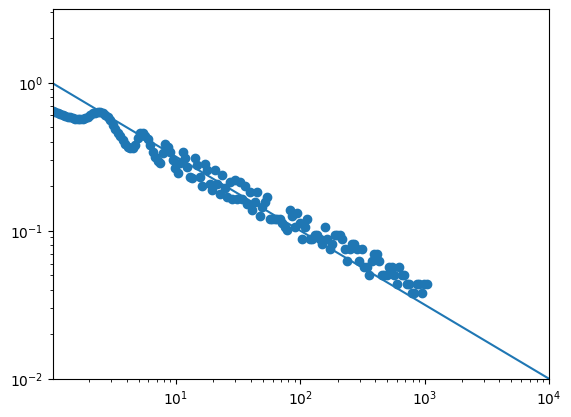

 76%|███████▌  | 151/200 [02:58<01:41,  2.06s/it]

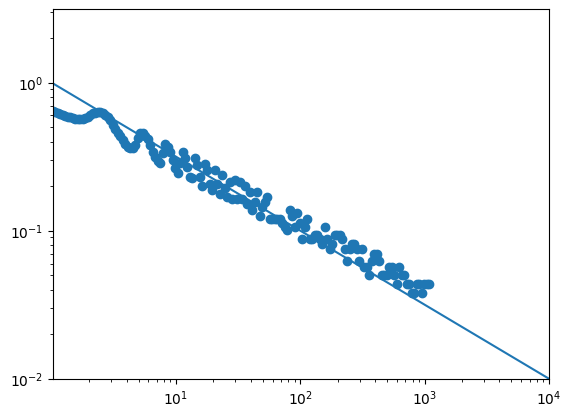

 76%|███████▌  | 152/200 [03:01<01:44,  2.18s/it]

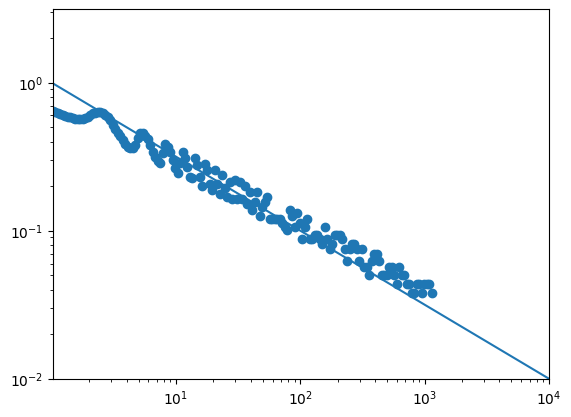

 76%|███████▋  | 153/200 [03:03<01:48,  2.30s/it]

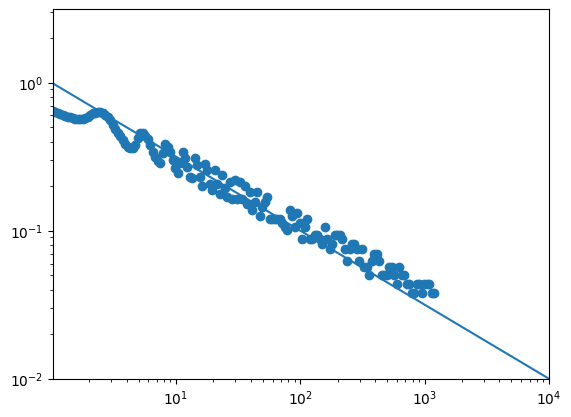

 77%|███████▋  | 154/200 [03:06<01:51,  2.42s/it]

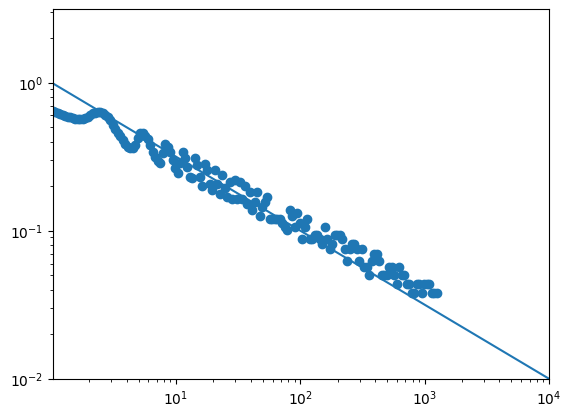

 78%|███████▊  | 155/200 [03:09<01:52,  2.49s/it]

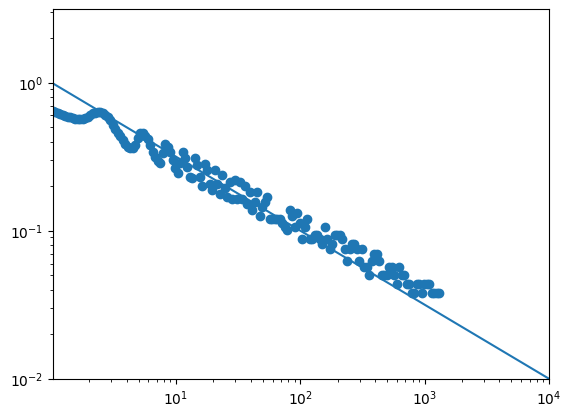

 78%|███████▊  | 156/200 [03:11<01:53,  2.58s/it]

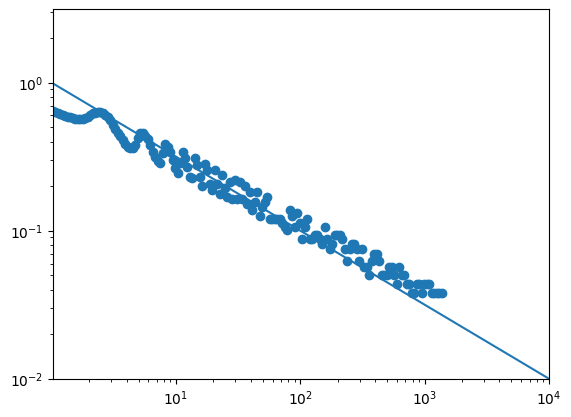

 78%|███████▊  | 157/200 [03:14<01:55,  2.69s/it]

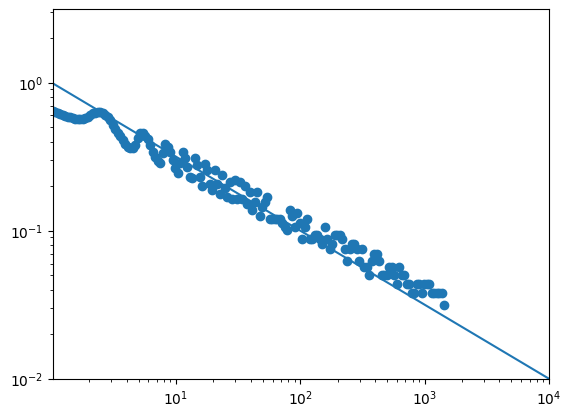

 79%|███████▉  | 158/200 [03:17<01:57,  2.81s/it]

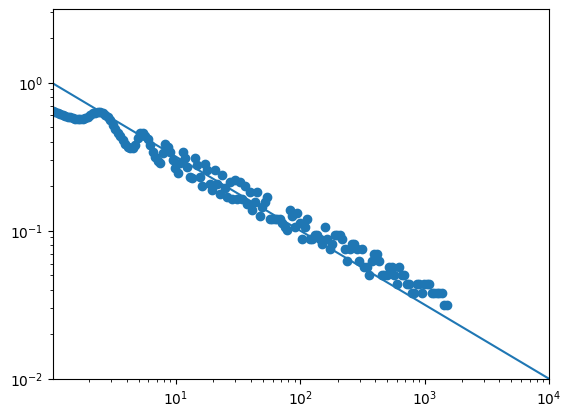

 80%|███████▉  | 159/200 [03:21<02:04,  3.04s/it]

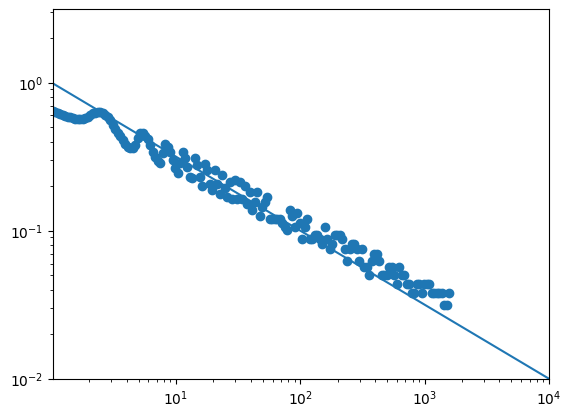

 80%|████████  | 160/200 [03:25<02:09,  3.24s/it]

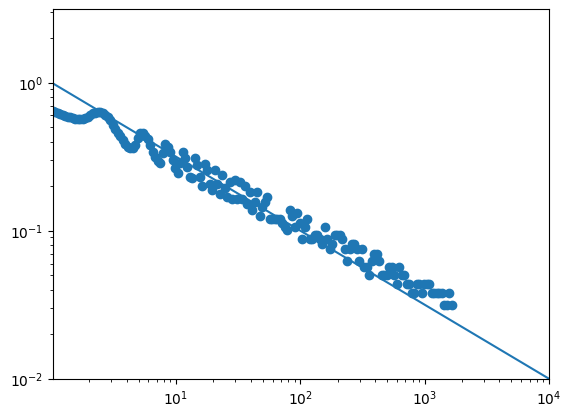

 80%|████████  | 161/200 [03:28<02:13,  3.42s/it]

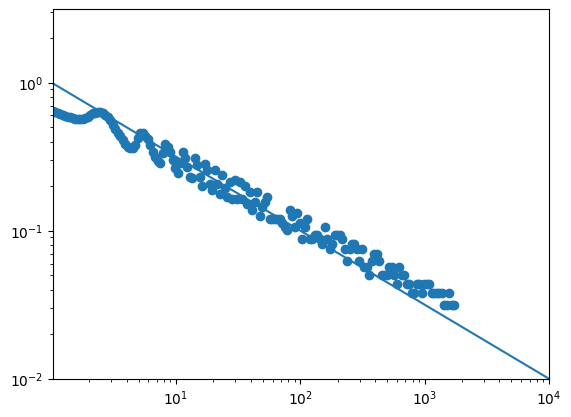

 81%|████████  | 162/200 [03:33<02:17,  3.62s/it]

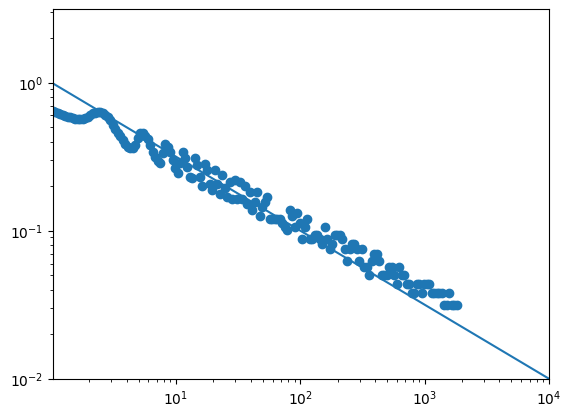

 82%|████████▏ | 163/200 [03:37<02:22,  3.86s/it]

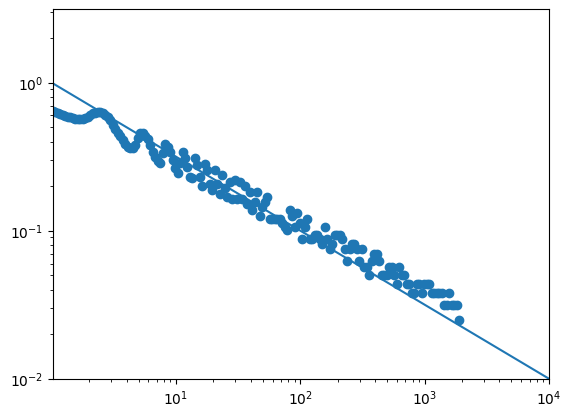

 82%|████████▏ | 164/200 [03:42<02:29,  4.14s/it]

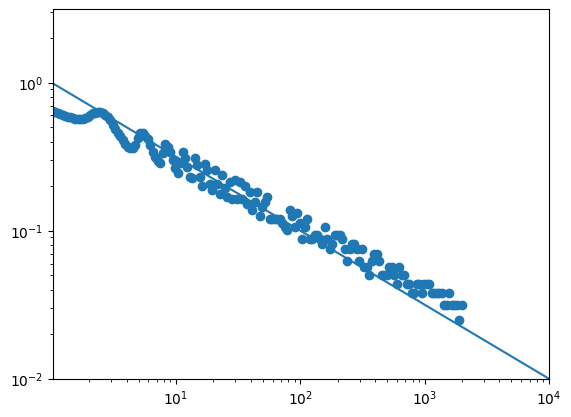

 82%|████████▎ | 165/200 [03:47<02:36,  4.47s/it]

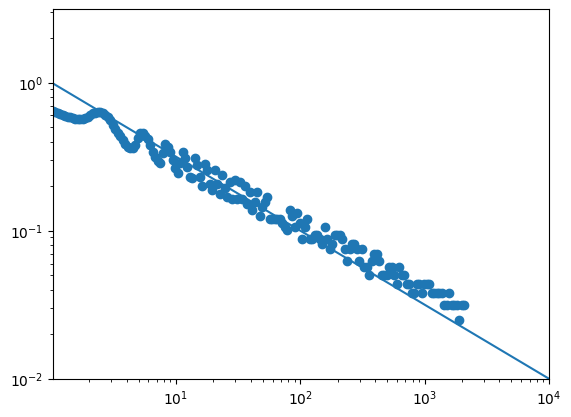

 83%|████████▎ | 166/200 [03:53<02:45,  4.86s/it]

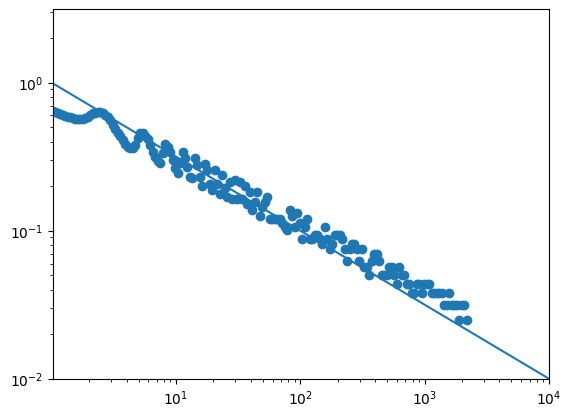

 84%|████████▎ | 167/200 [03:59<02:53,  5.26s/it]

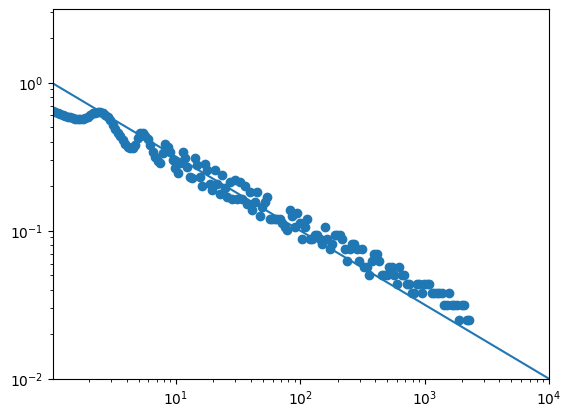

 84%|████████▍ | 168/200 [04:06<03:02,  5.71s/it]

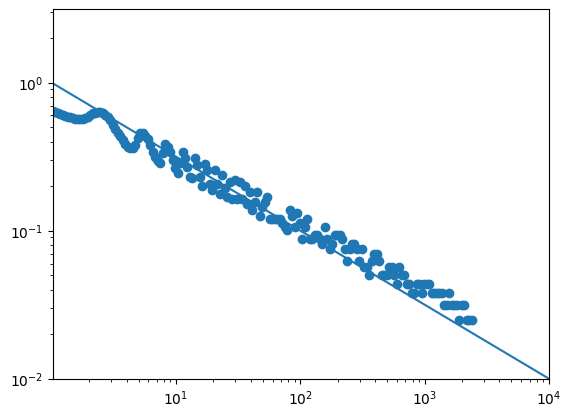

 84%|████████▍ | 169/200 [04:13<03:13,  6.23s/it]

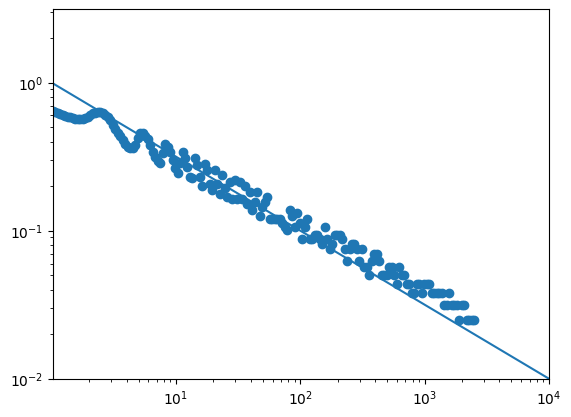

 85%|████████▌ | 170/200 [04:21<03:25,  6.84s/it]

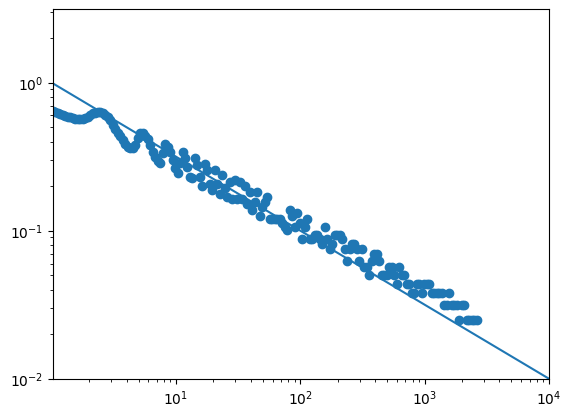

 86%|████████▌ | 171/200 [04:30<03:35,  7.44s/it]

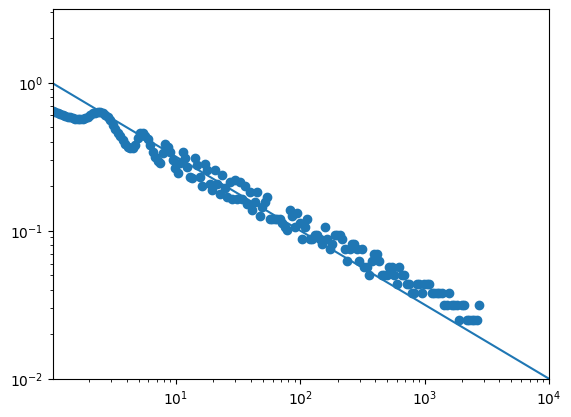

 86%|████████▌ | 172/200 [04:40<03:51,  8.25s/it]

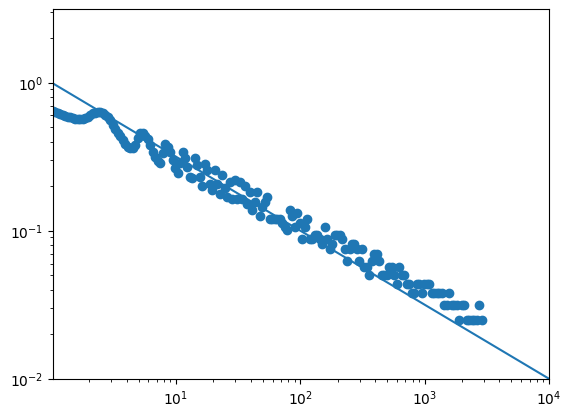

 86%|████████▋ | 173/200 [04:52<04:05,  9.10s/it]

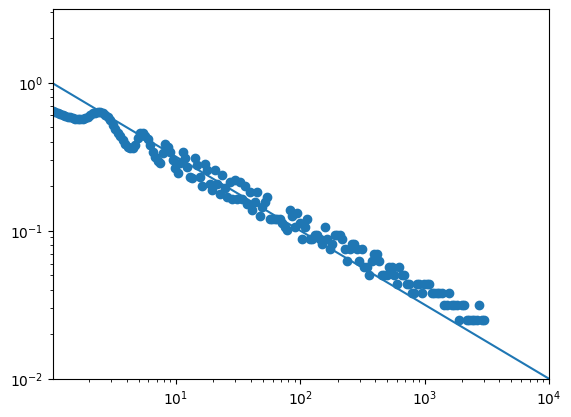

 87%|████████▋ | 174/200 [05:03<04:16,  9.85s/it]

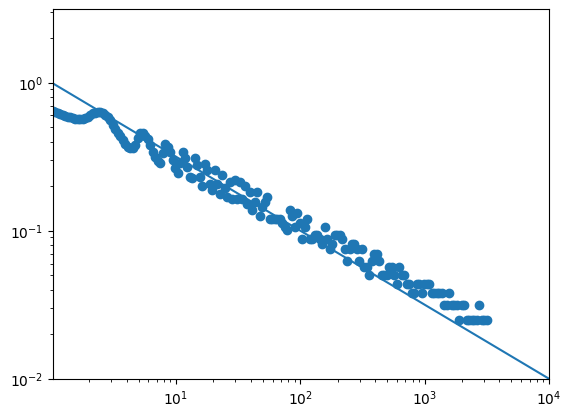

 88%|████████▊ | 175/200 [05:17<00:45,  1.81s/it]


KeyboardInterrupt: 

In [523]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.figure()
taus = np.logspace(0.01, 4, 200)
good_dat = []

plt.xscale("log")
plt.xlim(taus[0], taus[-1])
plt.ylim(0, np.pi)
plt.xlabel("tau")
plt.ylabel("q_min")

for i, tau in enumerate(tqdm(taus)):
    qs = np.linspace(0.01, np.pi, 500)
    dat = np.array([np.abs(kz.v_tilde(tau, q, tau))**2 for q in qs])
    good_dat.append(qs[np.argmin(dat)])

    plt.cla()
    plt.xscale("log")
    plt.xlim(taus[0], taus[-1])
    plt.ylim(.01, np.pi)
    plt.scatter(taus[:i+1], np.abs(pi-array(good_dat)))
    loglog()
    plot(taus,taus**(-1/2))

    plt.pause(0.01)

plt.show()

3.11967234337301


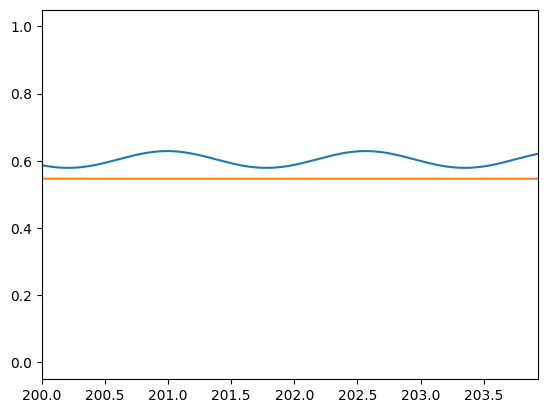

In [87]:
tau = 200
g0=5
tf = tau
args = (tau,tf)

ks = np.linspace(0,pi,30)
dat=[]

kstar=pi-sqrt(1/tau)*0.31
print(kstar)
t_eval = np.concatenate( (np.linspace(-(g0-1)*tau,tau,3), np.linspace(tau+.001,tau+5*pi/4,4000)))

u0,v0,k0 = groundstate(g0,kstar)
uf,vf,kf = groundstate(0,kstar)
us,vs=nq.evolve_mode(k0,nq.g_linear_hold,t_eval,u0,v0,args)
Final_overlap = np.abs(np.conj(vf)*us+np.conj(uf)*vs)**2

LE= np.abs(np.conj(us[0])*us+np.conj(vs[0])*vs)**2
plot(t_eval,-log(LE))
#ylim(-.1,1.1)
xlim(tau,t_eval[-1])
plot(t_eval,Final_overlap)

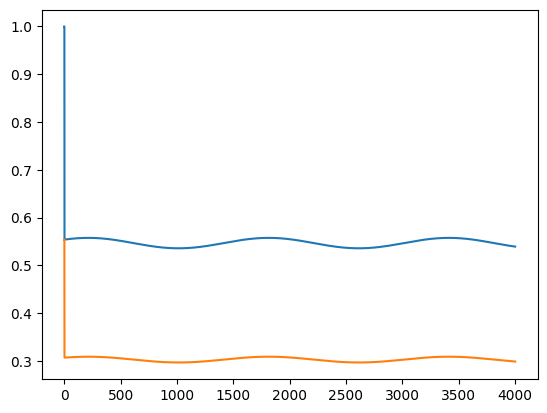

In [95]:
plot(np.abs(np.conj(vs[0])*vs)**2)
plot(np.abs(np.conj(vs[3])*vs)**2)
